# Multiple Game Analysis

## Loading all the libraries

In [25]:
!pip install adjustText
import matplotlib.pyplot as plt
import numpy as np
from adjustText import *
import pandas as pd
from plotnine import *
import scipy.stats as st
from scipy.interpolate import interp1d

from matplotlib.ticker import MaxNLocator
%matplotlib inline

# Game Set for Analysis

Each game to evaluate should be on a different line in "games".

In [83]:
fileprefix = "../CardStock/output/TraditionalTestbed/"
games = [
    {"game":"Agram","name":"Agram", "player":3},
#    {"game":"Blackjack","name":"Blackjack", "player":1},
#    {"game":"CrazyEights","name":"Crazy Eights", "player":3},
#    {"game":"Cribbage","name":"Cribbage", "player":2},
    {"game":"Cuckoo","name":"Cuckoo", "player":6},
#    {"game":"Euchre","name":"Euchre", "player":4},
#    {"game":"GoFish","name":"Go Fish", "player":4},
    {"game":"GolfSix","name":"Golf-6", "player":4},
    {"game":"GOPS","name":"Goofspiel", "player":2},
#    {"game":"Hearts","name":"Hearts", "player": 4},
#    {"game":"Klaverjassen","name":"Klaverjassen", "player":4},
    {"game":"LeducPoker","name":"Leudec Hold'em", "player":2},
#    {"game":"Pitch","name":"Pitch", "player":4},
#    {"game":"President","name":"President", "player":5},
#    {"game":"Rummy","name":"Rummy", "player":2},
#    {"game":"Schwimmen","name":"Schwimmen", "player":5},
#    {"game":"Scopa","name":"Scopa", "player":2},
#    {"game":"Skittgube","name":"Skittgube", "player":3},
#    {"game":"Sueca","name":"Sueca", "player":4},
#    {"game":"Whist","name":"Whist", "player":4},    
]
gameframe = pd.DataFrame.from_dict(games)
gameframe

,game,name,player
0,Agram,Agram,3
1,Cuckoo,Cuckoo,6
2,GolfSix,Golf-6,4
3,GOPS,Goofspiel,2
4,LeducPoker,Leudec Hold'em,2


In [41]:
fileprefix = "../CardStock/output/"
games = [

    {"game":"ShastaSam","name":"Shasta Sam", "player":2},
    {"game":"Coloretto","name":"Coloretto", "player":4},
    {"game":"Comet","name":"Comet", "player":2},
#    {"game":"Coup","name":"Coup", "player":4},
    {"game":"Escoba","name":"Escoba", "player":2},
    {"game":"LostCities","name":"Lost Cities", "player":2},
    {"game":"LAMA","name":"LAMA", "player":4},
    {"game":"NoThanks","name":"No Thanks", "player":4},
    {"game":"PageOne","name":"Page One", "player":3},
    {"game":"SaneEights","name":"Sane Eights", "player":4},
    {"game":"Simon'sCat","name":"Simon's Cat", "player":4},
    {"game":"SpiteMalice","name":"Spite and Malice", "player":2},
    {"game":"TurnTheTide","name":"Turn The Tide", "player":3},
    {"game":"BottleImp","name":"The Bottle Imp", "player":3},
    {"game":"Pairs","name":"Pairs", "player":3},
    {"game":"Clocktowers","name":"Clocktowers", "player":2},
    {"game":"Briscola","name":"Briscola", "player":2},
    {"game":"Trifle","name":"Trifle", "player":2},
    {"game":"SixNimmt","name":"6 Nimmt", "player":5},
    {"game":"FoxInTheForest","name":"The Fox in the Forest", "player":2},
    
]
gameframe = pd.DataFrame.from_dict(games)
gameframe

,game,name,player
0,ShastaSam,Shasta Sam,2
1,Coloretto,Coloretto,4
2,Comet,Comet,2
3,Escoba,Escoba,2
4,LostCities,Lost Cities,2
5,LAMA,LAMA,4
6,NoThanks,No Thanks,4
7,PageOne,Page One,3
8,SaneEights,Sane Eights,4
9,Simon'sCat,Simon's Cat,4


# Branching Factor

This first gather data into a dataframe, which will enable us to draw graphs to show how the branching factor of the game changes over time.

This data is from games with all **random** players.

In [84]:
first = True
for index, row in gameframe.iterrows():
    gf = pd.read_csv(fileprefix + row["game"] + "/" + str(row["player"]) + "/" + "R" * row["player"] + "/choice.csv")
    print(row["game"])
    gf["game"] = row["game"]
    if first:
        choiceframe = gf
        first = False
    else:
        choiceframe = pd.concat([choiceframe, gf])
    gf = pd.read_csv(fileprefix + row["game"] + "/" + str(row["player"]) + "/" + "P" + "R" * (row["player"] - 1) + "/choice.csv")
    gf["game"] = row["game"]
    choiceframe = pd.concat([choiceframe, gf])

Agram
Cuckoo
GolfSix
GOPS
LeducPoker


In [85]:
choiceframe

,game,numPlayers,ai,run,move,player,choices,choice,time
0,Agram,3,RRR,1,1,1,6,2,0
1,Agram,3,RRR,1,2,2,6,4,0
2,Agram,3,RRR,1,3,3,6,3,0
3,Agram,3,RRR,1,4,1,5,5,0
4,Agram,3,RRR,1,5,2,1,1,0
...,...,...,...,...,...,...,...,...,...
358,LeducPoker,2,PR,100,2,2,2,2,0
359,LeducPoker,2,PR,100,3,1,2,2,0
360,LeducPoker,2,PR,100,4,2,2,1,1
361,LeducPoker,2,PR,100,5,1,2,2,0


## Convergence

The **Convergence** is a summary, the average slope of all the runs for a game, squished into a number between 0 and 1. 0.5 means a flat horizontal line, 0 is straight up, and 1 is straight down.

In [86]:
cseq = []
cf = choiceframe[choiceframe["ai"].str.startswith("R")]
for index, row in gameframe.iterrows():
    cf2 = cf[(cf["game"]==row["game"])]
    convergence = 0
    count = 0
    for i in range(100):
        tempf = cf2[(cf2["run"]==i)]
        if len(tempf) > 1:
            slope, intercept, r_value, p_value, std_error = st.linregress(tempf["move"], tempf["choices"])
            convergence += (1 - (slope / 2 + 0.5))
            count += 1
    cseq.append(convergence / count)

In [87]:
gameframe["convergence"] = cseq
gameframe

,game,name,player,convergence
0,Agram,Agram,3,0.593797
1,Cuckoo,Cuckoo,6,0.500866
2,GolfSix,Golf-6,4,0.505359
3,GOPS,Goofspiel,2,0.748889
4,LeducPoker,Leudec Hold'em,2,0.500000


## Plotting all games

This plot shows the branching factors over all of the games in the testbed for random players.

/opt/anaconda3/lib/python3.13/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 14 x 4 in image.
/opt/anaconda3/lib/python3.13/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: ChoicesRandom.png


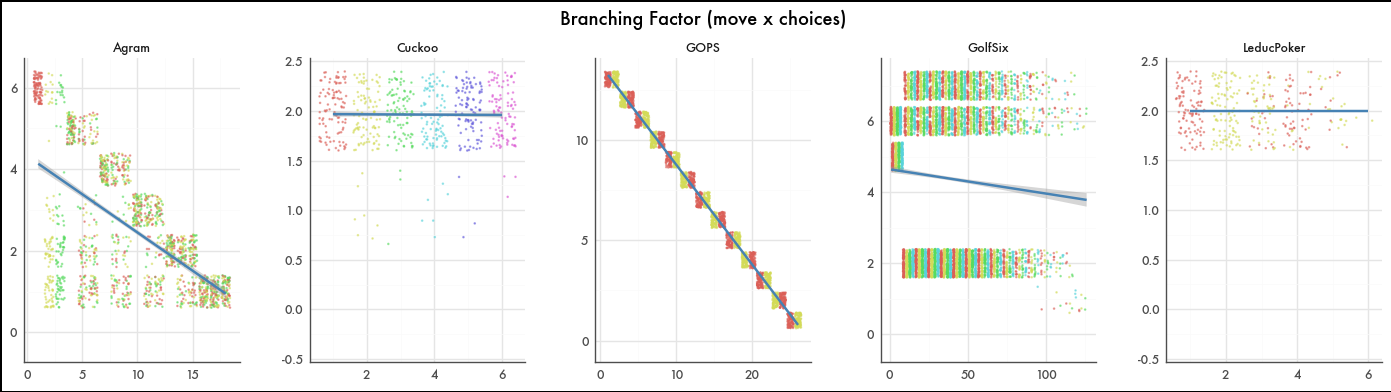

In [88]:
choiceframe["player"] = choiceframe["player"].astype(str)
cplot = (ggplot(choiceframe[choiceframe["ai"].str.startswith("R")], aes("move", "choices", color="player"))
 + geom_jitter(size=0.05, alpha=0.5)
 + geom_smooth(method="lm", color="steelblue")
 + facet_wrap("game", scales = "free", ncol = 7)
 + aes(ymin=0)
 + theme_minimal(base_family="Futura", base_size=11) 
 + theme(legend_position='none', figure_size=(14, 4))
 + theme(
        plot_background=element_rect(fill="white"),
        axis_line=element_line(color="#4d4d4d"),
        axis_ticks_major=element_line(color="#00000000"),
        axis_title=element_blank(),
        panel_spacing=0.03,
    )
 + labs(x='Move', y='Branching Factor', title="Branching Factor (move x choices)")
)
cplot.save("ChoicesRandom.png")
cplot.show()

/opt/anaconda3/lib/python3.13/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 14 x 4 in image.
/opt/anaconda3/lib/python3.13/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: ChoicesRandom.png


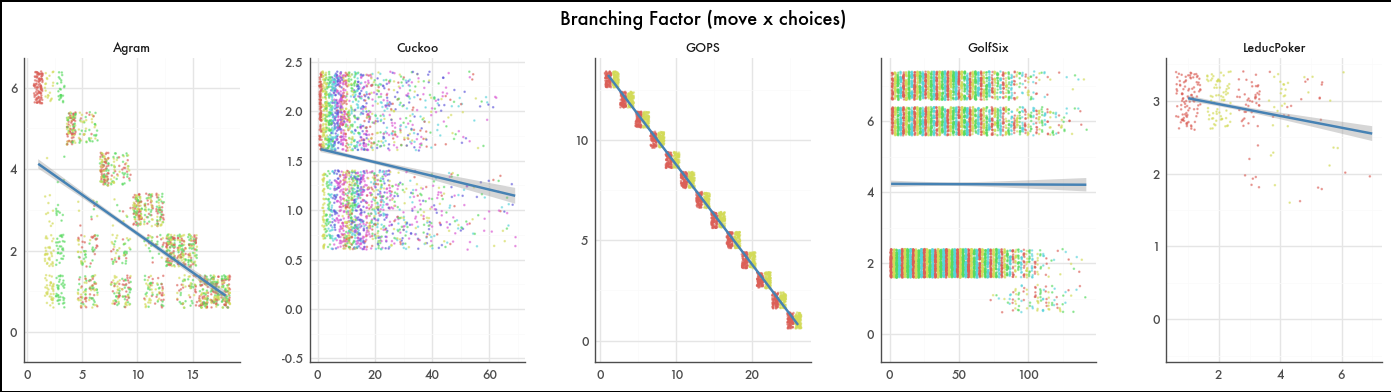

In [68]:
choiceframe["player"] = choiceframe["player"].astype(str)
cplot = (ggplot(choiceframe[choiceframe["ai"].str.startswith("R")], aes("move", "choices", color="player"))
 + geom_jitter(size=0.05, alpha=0.5)
 + geom_smooth(method="lm", color="steelblue")
 + facet_wrap("game", scales = "free", ncol = 7)
 + aes(ymin=0)
 + theme_minimal(base_family="Futura", base_size=11) 
 + theme(legend_position='none', figure_size=(14, 4))
 + theme(
        plot_background=element_rect(fill="white"),
        axis_line=element_line(color="#4d4d4d"),
        axis_ticks_major=element_line(color="#00000000"),
        axis_title=element_blank(),
        panel_spacing=0.03,
    )
 + labs(x='Move', y='Branching Factor', title="Branching Factor (move x choices)")
)
cplot.save("ChoicesRandom.png")
cplot.show()

This plot is the branching factor for the PIPMC players

/opt/anaconda3/lib/python3.13/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 14 x 7 in image.
/opt/anaconda3/lib/python3.13/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: ChoicesPIPMC.png


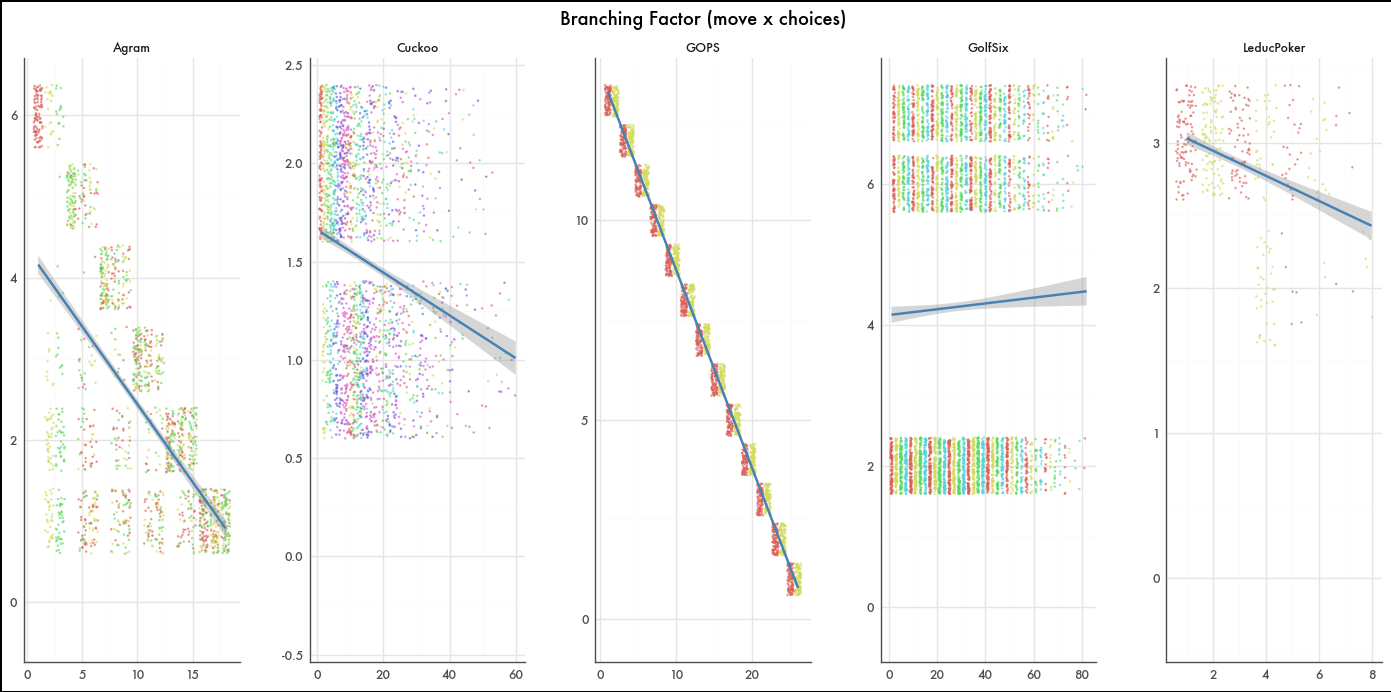

In [69]:
choiceframe["player"] = choiceframe["player"].astype(str)
cplot = (ggplot(choiceframe[choiceframe["ai"].str.startswith("P")], aes("move", "choices", color="player"))
 + geom_jitter(size=0.05, alpha=0.5)
 + geom_smooth(method="lm", color="steelblue")
 + facet_wrap("game", scales = "free", ncol = 7)
 + aes(ymin=0)
 + theme_minimal(base_family="Futura", base_size=11) 
 + theme(legend_position='none', figure_size=(14, 7))
 + theme(
        plot_background=element_rect(fill="white"),
        axis_line=element_line(color="#4d4d4d"),
        axis_ticks_major=element_line(color="#00000000"),
        axis_title=element_blank(),
        panel_spacing=0.03,
    )
 + labs(x='Move', y='Branching Factor', title="Branching Factor (move x choices)")
)
cplot.save("ChoicesPIPMC.png")
cplot.show()

And one plot that shows them all.

/opt/anaconda3/lib/python3.13/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 15 x 15 in image.
/opt/anaconda3/lib/python3.13/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: Choices.png


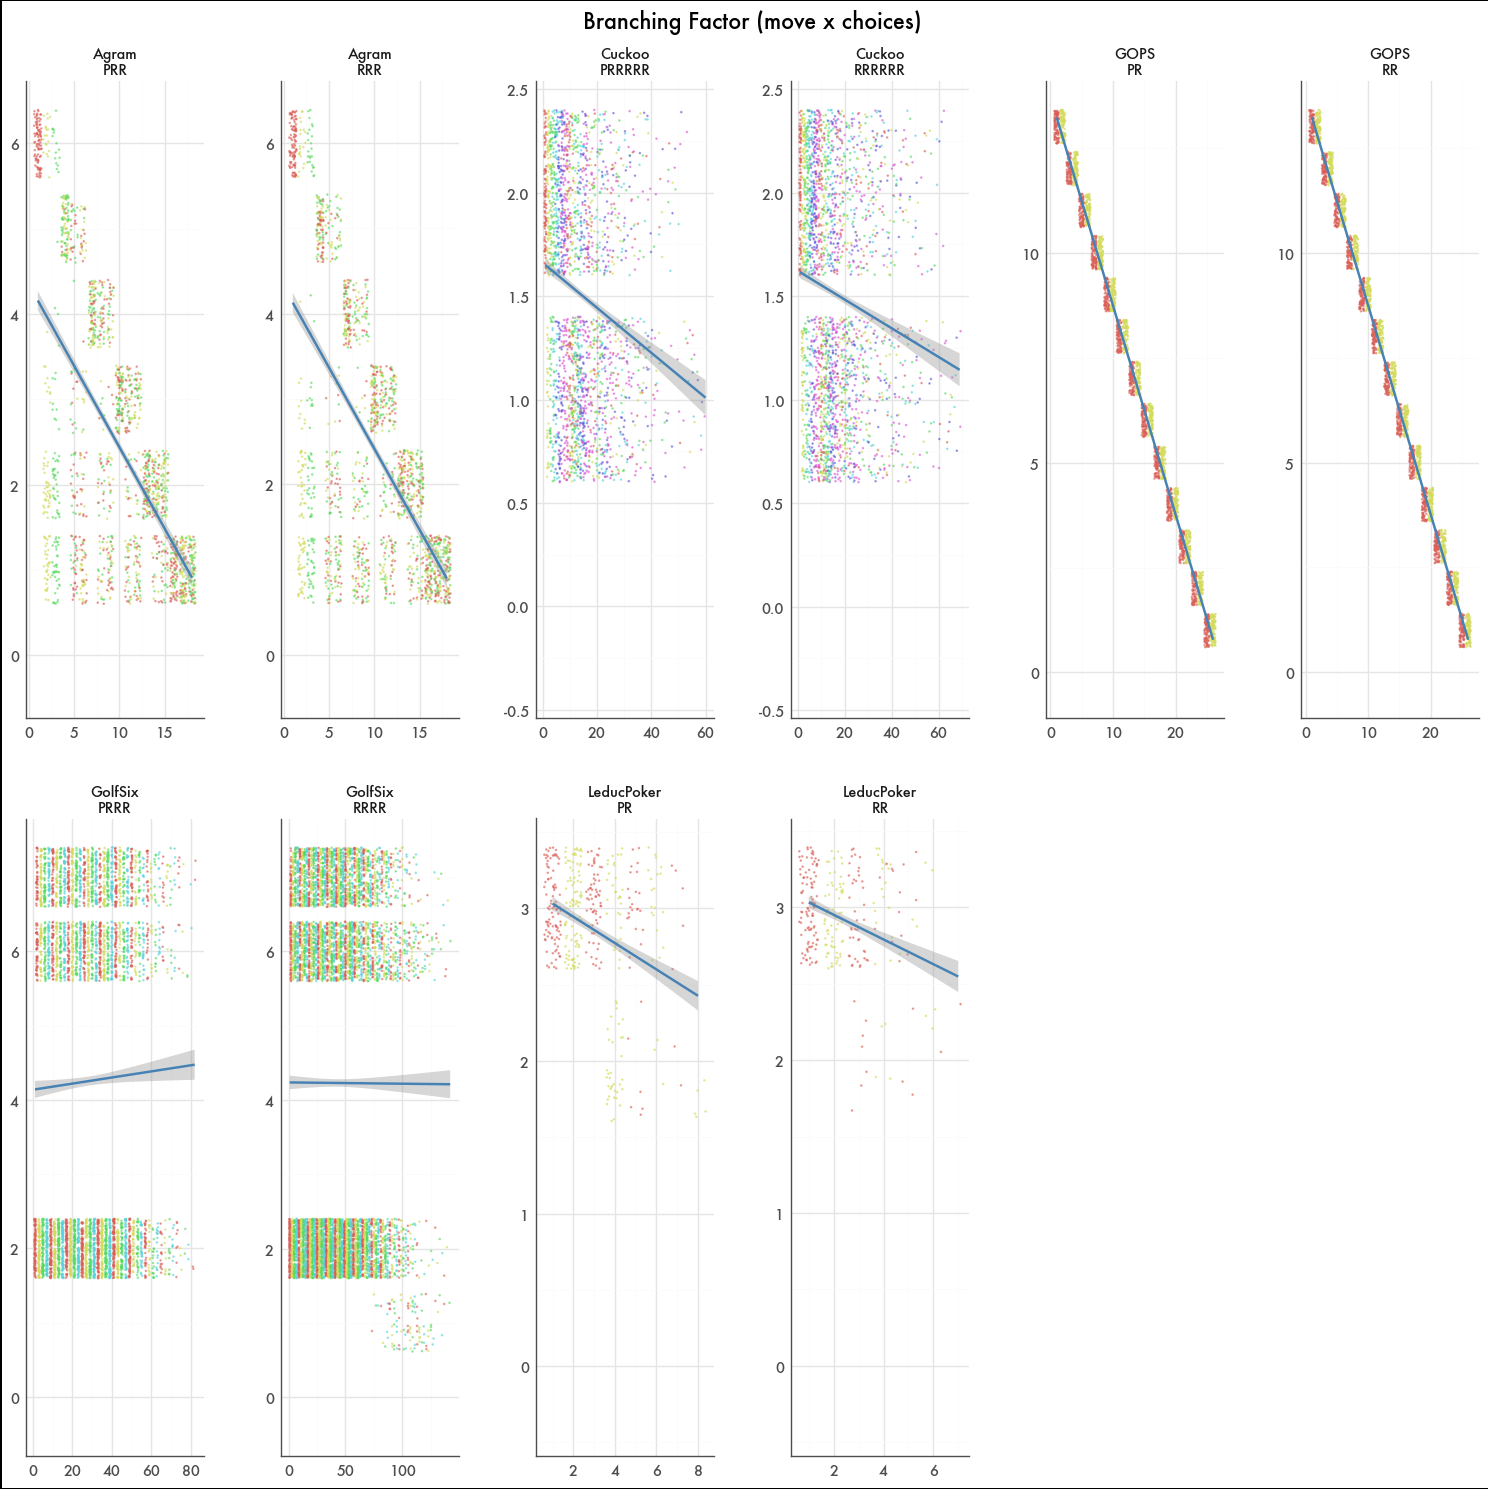

In [70]:
choiceframe["player"] = choiceframe["player"].astype(str)
cplot = (ggplot(choiceframe, aes("move", "choices", color="player"))
 + geom_jitter(size=0.05, alpha=0.5)
 + geom_smooth(method="lm", color="steelblue")
 + facet_wrap(["game", "ai"], scales = "free", ncol = 6)
 + aes(ymin=0)
 + theme_minimal(base_family="Futura", base_size=13) 
 + theme(legend_position='none', figure_size=(15, 15))
 + theme(
        plot_background=element_rect(fill="white"),
        axis_line=element_line(color="#4d4d4d"),
        axis_ticks_major=element_line(color="#00000000"),
        axis_title=element_blank(),
        panel_spacing=0.03,
    )
 + labs(x='Move', y='Branching Factor', title="Branching Factor (move x choices)")
)
cplot.save("Choices.png")
cplot.show()

# Game Length

We can calculate the average game length, by finding the max value for the move column on each run, then averaging

In [71]:
choiceframe[['game', 'run', 'move']][choiceframe["ai"].str.startswith("R")].groupby(['game', 'run'], as_index=False)['move'].max().groupby(['game'], as_index=False).mean()

,game,run,move
0,Agram,50.5,18.00
1,Cuckoo,50.5,24.64
2,GOPS,50.5,26.00
3,GolfSix,50.5,78.32
4,LeducPoker,50.5,2.67


In [72]:
lengthf = choiceframe[['game', 'run', 'move']][choiceframe["ai"].str.startswith("R")].groupby(['game', 'run'], as_index=False)['move'].max().groupby(['game'], as_index=False).mean()[['game', 'move']]
gameframe = gameframe.merge(lengthf, on='game', how='left')

In [73]:
gameframe

,game,name,player,convergence,move
0,Agram,Agram,3,0.595063,18.00
1,Cuckoo,Cuckoo,6,0.525290,24.64
2,GolfSix,Golf-6,4,0.499122,78.32
3,GOPS,Goofspiel,2,0.748889,26.00
4,LeducPoker,Leudec Hold'em,2,0.524107,2.67


# Fairness

For random games, we want to look at the distribution of win/loss percentages across the players.

In [74]:
first = True
for index, row in gameframe.iterrows():
    gf = pd.read_csv(fileprefix + row["game"] + "/" + str(row["player"]) + "/" + "R" * row["player"] + "/results.csv")
    if row["game"] == "Schwimmen":
        gf["score"] = gf["score"] / 2.0
    gf["game"] = row["game"]
    gf["ai"] = "Random"
    if first:
        resultsframe = gf
        first = False
    else:
        resultsframe = pd.concat([resultsframe, gf])
    gf = pd.read_csv(fileprefix + row["game"] + "/" + str(row["player"]) + "/" + "P" + "R" * (row["player"] - 1) + "/results.csv")
    if row["game"] == "Schwimmen":
        gf["score"] = gf["score"] / 2.0
    gf["game"] = row["game"]
    gf["ai"] = "PIMC"
    resultsframe = pd.concat([resultsframe, gf])

resultsframe["player"] = resultsframe["player"].astype(str)
resultsframe["rank"] = resultsframe["rank"].astype(str)
resultsframe

,game,numPlayers,ai,run,player,score,rank,time
0,Agram,3,Random,1,1,0,2,3909
1,Agram,3,Random,1,2,1,1,3909
2,Agram,3,Random,1,3,0,2,3909
3,Agram,3,Random,2,1,0,2,3655
4,Agram,3,Random,2,2,0,2,3655
...,...,...,...,...,...,...,...,...
195,LeducPoker,2,PIMC,98,2,0,1,37
196,LeducPoker,2,PIMC,99,1,3,1,30
197,LeducPoker,2,PIMC,99,2,-3,2,30
198,LeducPoker,2,PIMC,100,1,-1,2,30


In [75]:
rf2 = resultsframe.groupby(['game', 'player', 'rank', 'ai'], as_index=False).count()
rf3 = rf2[(rf2["player"]=="1") & (rf2["rank"] == "1")][["game", "ai", "run"]]
rf3["run"] = rf3["run"] / 100
rf4 = rf3.pivot(index='game', columns='ai')
rf4 = rf4["run"].reset_index()
rf4.columns.name=None
rf5 = rf4.merge(gameframe, on='game', how='left')
rf5

,game,PIMC,Random,name,player,convergence,move
0,Agram,0.50,0.41,Agram,3,0.595063,18.00
1,Cuckoo,0.94,0.78,Cuckoo,6,0.525290,24.64
2,GOPS,0.87,0.54,Goofspiel,2,0.748889,26.00
3,GolfSix,0.86,0.23,Golf-6,4,0.499122,78.32
4,LeducPoker,0.95,0.40,Leudec Hold'em,2,0.524107,2.67


In [76]:
def fairness(wp, np):
    if np == 1:
        return 1
    if wp < 1 / np:
        return wp * np
    else:
        return (np - np * wp) / (np - 1)
rf5["fairness"] = rf5.apply(lambda x: fairness(x.Random, x.player), axis=1)
def order(aiwp, np):
    if np == 1:
        return 1
    ewp = 1 / np
    return (aiwp - ewp) / (1 - ewp)
rf5["order"] = rf5.apply(lambda x: order(x.PIMC, x.player), axis=1)
rf5["gain"] = rf5.apply(lambda x: x.PIMC - x.Random, axis=1)
rf5

,game,PIMC,Random,name,player,convergence,move,fairness,order,gain
0,Agram,0.50,0.41,Agram,3,0.595063,18.00,0.885,0.250000,0.09
1,Cuckoo,0.94,0.78,Cuckoo,6,0.525290,24.64,0.264,0.928000,0.16
2,GOPS,0.87,0.54,Goofspiel,2,0.748889,26.00,0.920,0.740000,0.33
3,GolfSix,0.86,0.23,Golf-6,4,0.499122,78.32,0.920,0.813333,0.63
4,LeducPoker,0.95,0.40,Leudec Hold'em,2,0.524107,2.67,0.800,0.900000,0.55


In [77]:
gameframe = gameframe.merge(rf5[["game", "fairness", "order", "gain", "PIMC"]], on="game", how="left")

In [78]:
gameframe

,game,name,player,convergence,move,fairness,order,gain,PIMC
0,Agram,Agram,3,0.595063,18.00,0.885,0.250000,0.09,0.50
1,Cuckoo,Cuckoo,6,0.525290,24.64,0.264,0.928000,0.16,0.94
2,GolfSix,Golf-6,4,0.499122,78.32,0.920,0.813333,0.63,0.86
3,GOPS,Goofspiel,2,0.748889,26.00,0.920,0.740000,0.33,0.87
4,LeducPoker,Leudec Hold'em,2,0.524107,2.67,0.800,0.900000,0.55,0.95


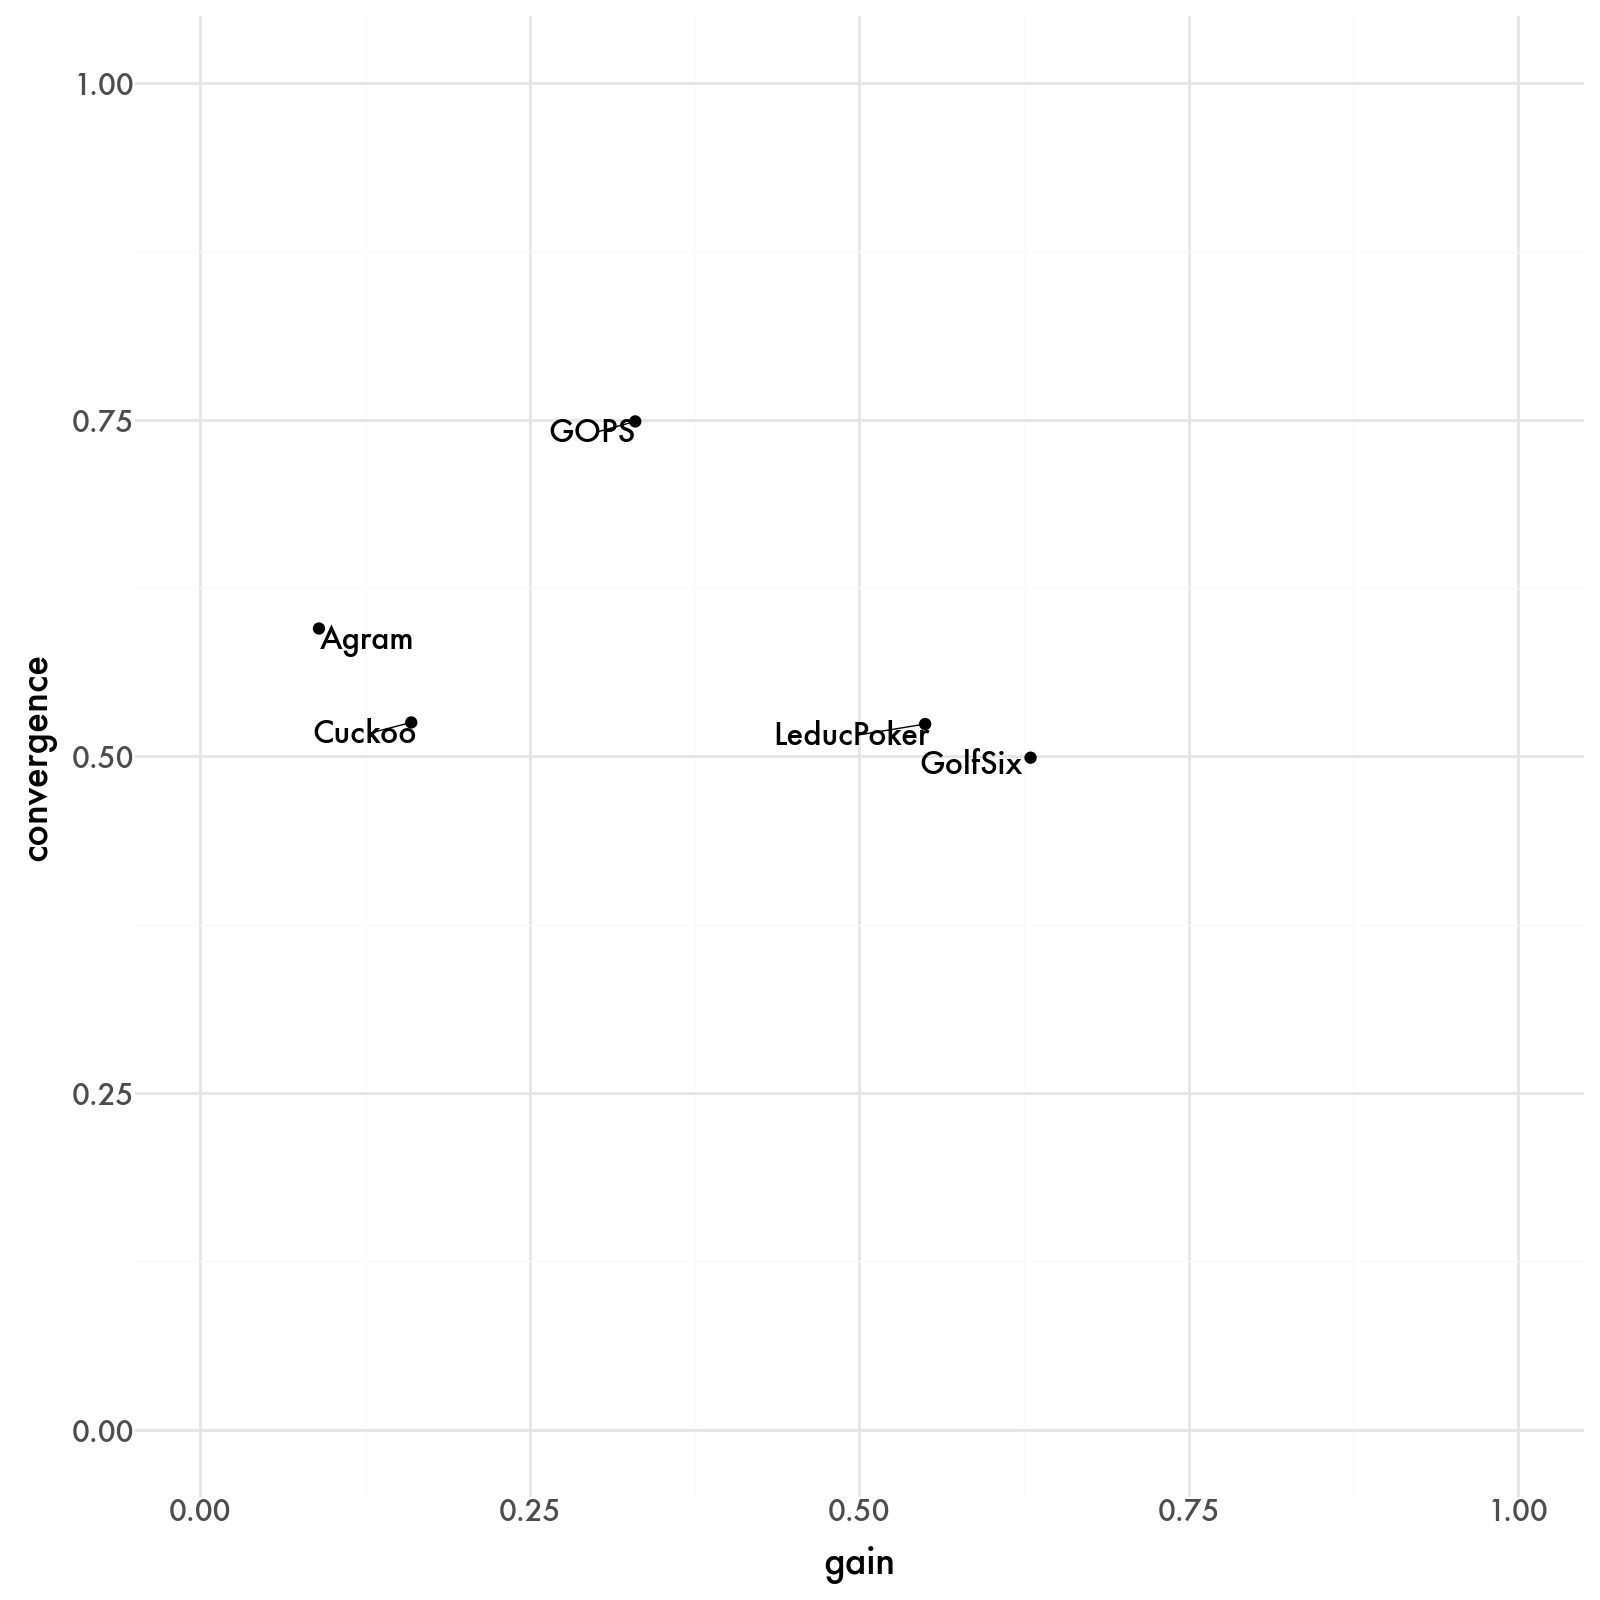

In [79]:
(ggplot(gameframe, aes("gain", "convergence", label="game"))
 + geom_point()
 + xlim(0, 1)
 + ylim(0, 1)
 + geom_text(adjust_text={"arrowprops": {"arrowstyle": "-"}})
 + theme_minimal(base_family="Futura", base_size=13)
 + theme(figure_size=(8, 8))
)

/opt/anaconda3/lib/python3.13/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 8 x 5 in image.
/opt/anaconda3/lib/python3.13/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: Ranks.png


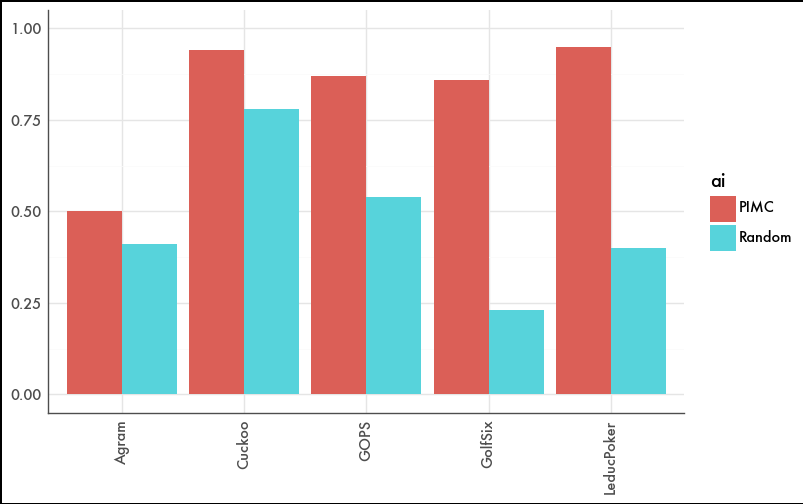

In [80]:
rplot = (ggplot(rf3, aes("game", "run", fill="ai"))
 + geom_bar(position="dodge", stat="identity")
 + theme_minimal(base_family="Futura", base_size=13)
 + theme(figure_size=(8, 5))
 + theme(
        axis_text_x=element_text(rotation=90),
        plot_background=element_rect(fill="white"),
        axis_line=element_line(color="#4d4d4d"),
        axis_ticks_major=element_line(color="#00000000"),
        axis_title=element_blank(),
        panel_spacing=0.03,
    )
 + ylim(0, 1)
 + labs(x='player', y='rank')
)
rplot.save("Ranks.png")
rplot.show()

/opt/anaconda3/lib/python3.13/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 14 x 7 in image.
/opt/anaconda3/lib/python3.13/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: AIBarRanks.png


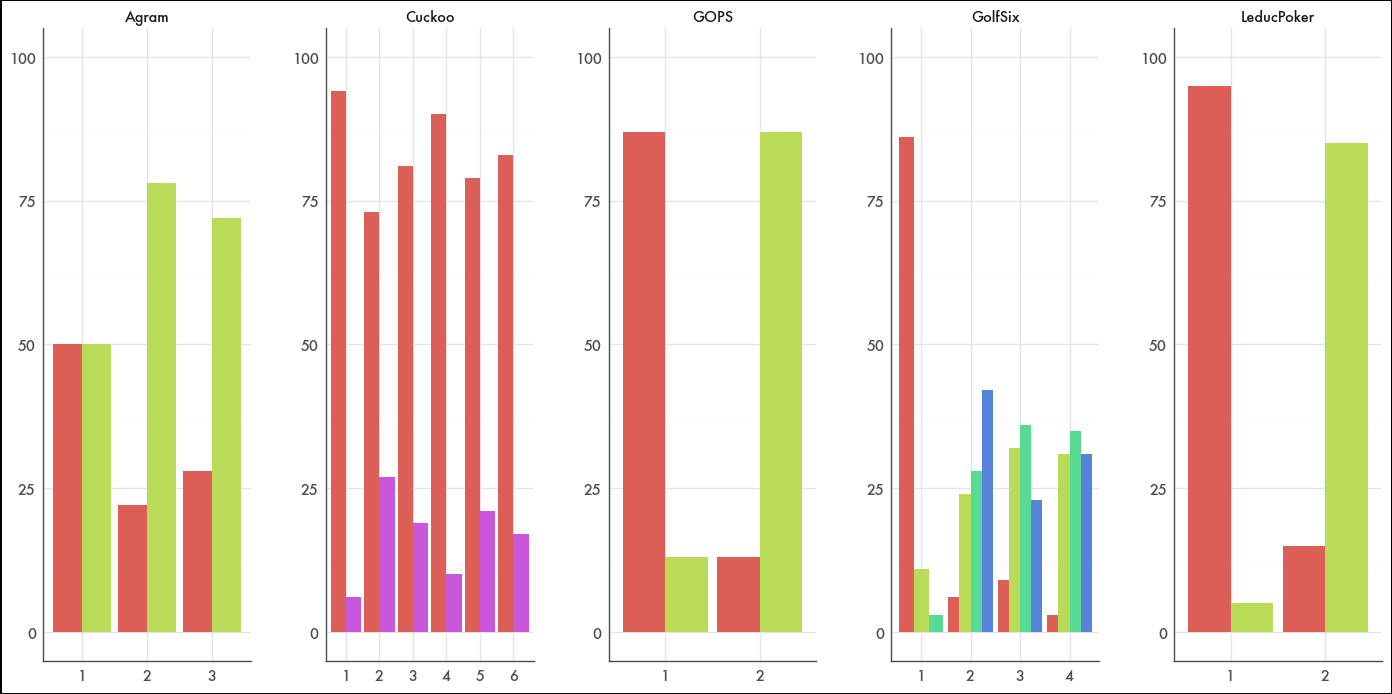

In [81]:
rplot = (ggplot(rf2[rf2["ai"]=="PIMC"], aes("player", "run", fill="rank"))
 + geom_bar(position="dodge", stat="identity")
 + facet_wrap("game", scales = "free", ncol=7)
 + theme_minimal(base_family="Futura", base_size=13)
 + theme(legend_position='none', figure_size=(14, 7))
 + theme(
        plot_background=element_rect(fill="white"),
        axis_line=element_line(color="#4d4d4d"),
        axis_ticks_major=element_line(color="#00000000"),
        axis_title=element_blank(),
        panel_spacing=0.03,
    )
 + ylim(0, 100)
 + labs(x='player', y='rank')
)
rplot.save("AIBarRanks.png")
rplot.show()

/opt/anaconda3/lib/python3.13/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 14 x 7 in image.
/opt/anaconda3/lib/python3.13/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: RandomScores.png


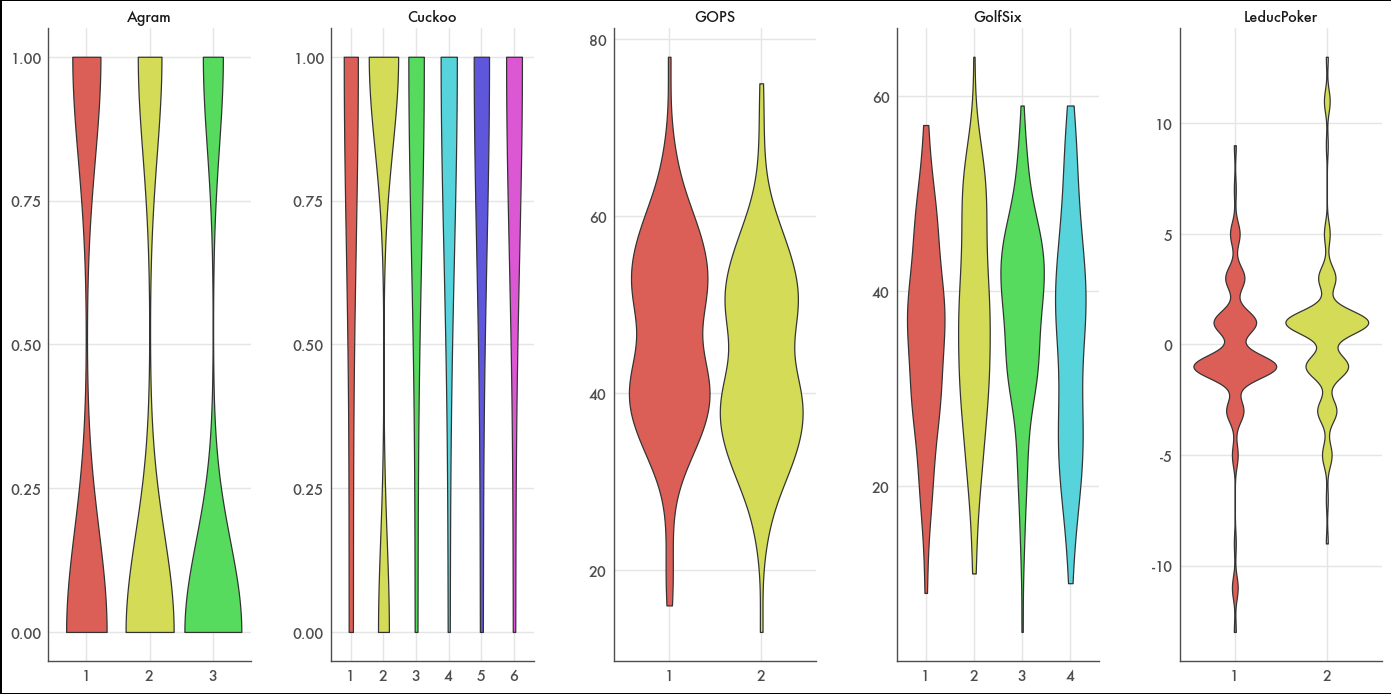

In [82]:
splot = (ggplot(resultsframe[resultsframe["ai"].str.startswith("R")], aes("player", "score", fill="player"))
 + geom_violin()
 + facet_wrap("game", scales = "free", ncol=7)
 + theme_minimal(base_family="Futura", base_size=13)
 + theme(legend_position='none', figure_size=(14, 7))
 + theme(
        plot_background=element_rect(fill="white"),
        axis_line=element_line(color="#4d4d4d"),
        axis_ticks_major=element_line(color="#00000000"),
        axis_title=element_blank(),
        panel_spacing=0.03,
    )
 + labs(x='player', y='rank')
 + scale_y_continuous(minor_breaks=False)
)
splot.save("RandomScores.png")
splot.show()

In [103]:
rf2 = resultsframe[resultsframe["ai"].str.startswith("P")].groupby(['game', 'player', 'rank'], as_index=False).count()

/opt/anaconda3/lib/python3.13/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 14 x 7 in image.
/opt/anaconda3/lib/python3.13/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: AIRanks.png


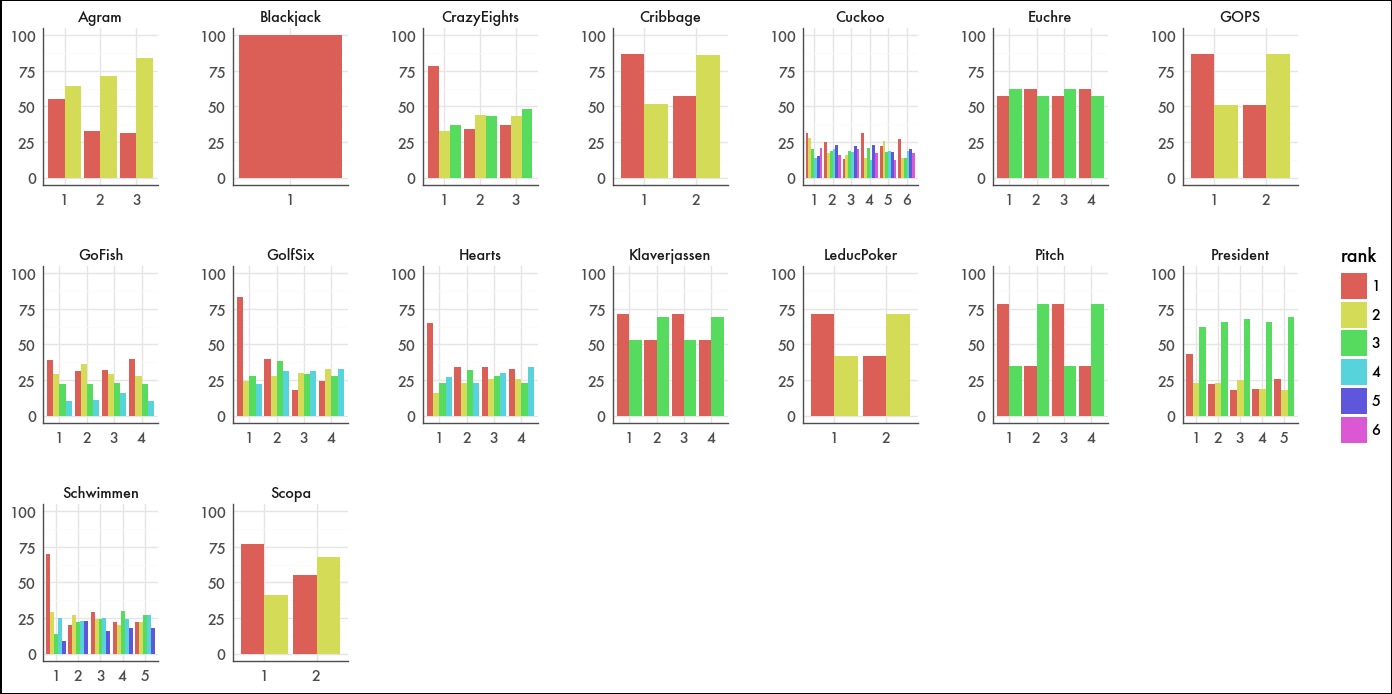

In [22]:
rplot = (ggplot(rf2, aes("player", "run", fill="rank"))
 + geom_bar(position="dodge", stat="identity")
 + facet_wrap("game", scales = "free", ncol=7)
 + theme_minimal(base_family="Futura", base_size=13)
 + theme(figure_size=(14, 7))
 + ylim(0, 100)
 + theme(
        plot_background=element_rect(fill="white"),
        axis_line=element_line(color="#4d4d4d"),
        axis_ticks_major=element_line(color="#00000000"),
        axis_title=element_blank(),
        panel_spacing=0.03,
    )
 + labs(x='player', y='rank')
)
rplot.save("AIRanks.png")
rplot.show()

/opt/anaconda3/lib/python3.13/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 15 x 15 in image.
/opt/anaconda3/lib/python3.13/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: AllScores.png


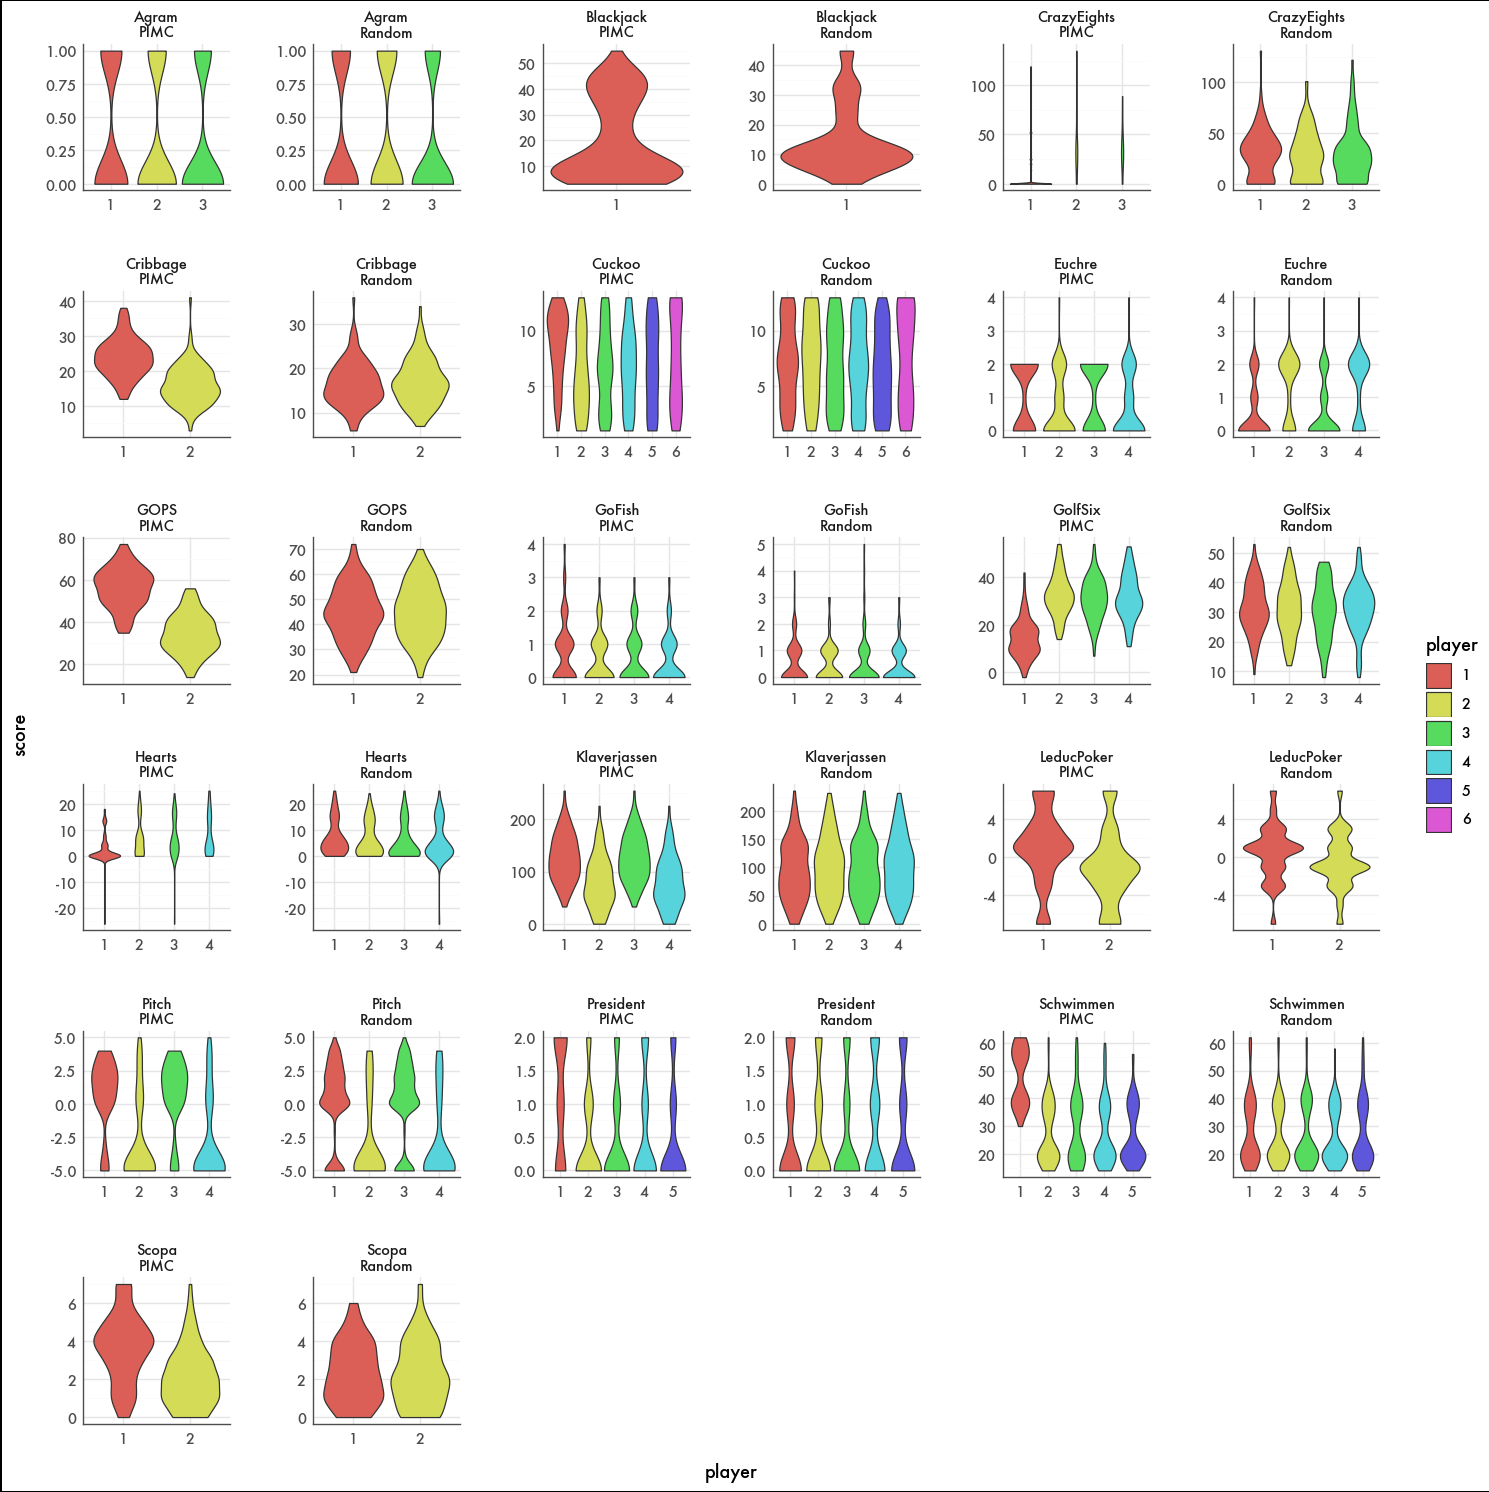

In [105]:
splot = (ggplot(resultsframe, aes("player", "score", fill="player"))
 + geom_violin()
 + facet_wrap(["game", "ai"], scales = "free", ncol = 6)
 + theme_minimal(base_family="Futura", base_size=13)
 + theme(figure_size=(15, 15))
 + theme(
        plot_background=element_rect(fill="white"),
        axis_line=element_line(color="#4d4d4d"),
        axis_ticks_major=element_line(color="#00000000"),
        panel_spacing=0.03,
    )
 + labs(x='player', y='score')
)
splot.save("AllScores.png")
splot.show()

/opt/anaconda3/lib/python3.13/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 14 x 7 in image.
/opt/anaconda3/lib/python3.13/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: PvsRScores.png


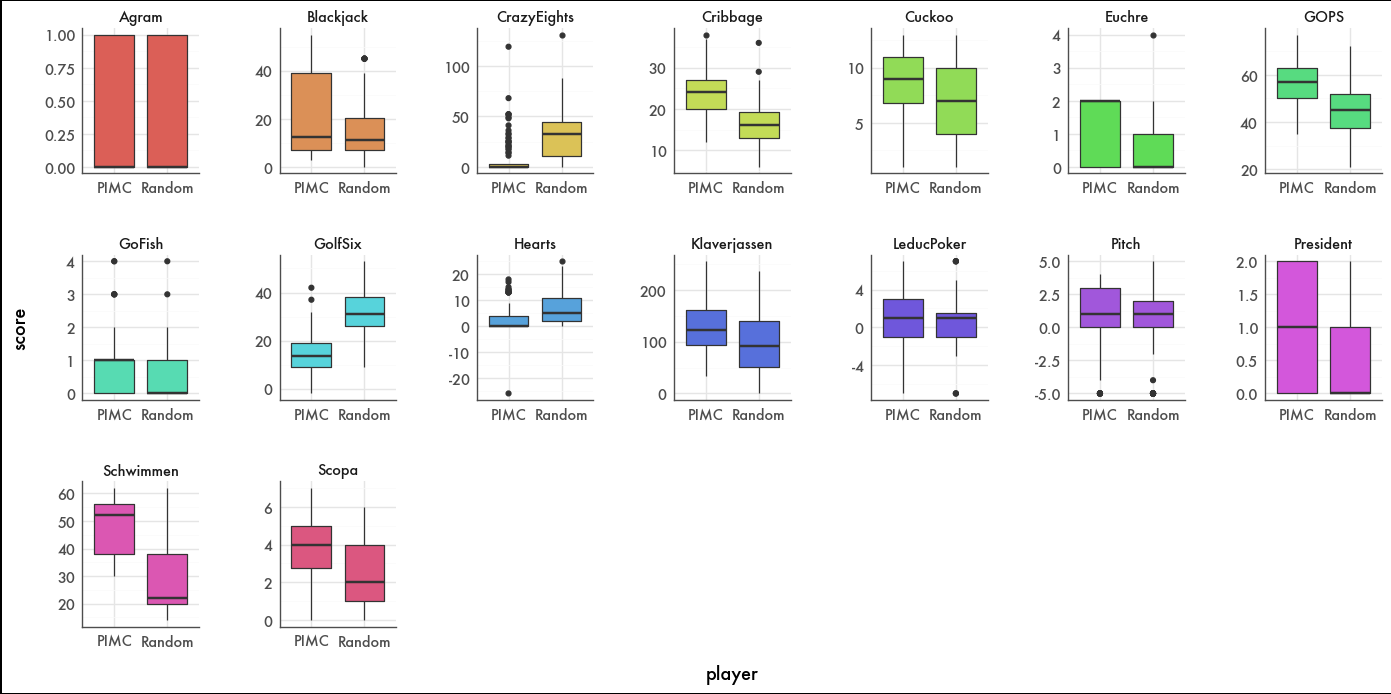

In [106]:
resultsframe["rank"] = resultsframe["rank"].astype(int)

splot = (ggplot(resultsframe[resultsframe["player"]=="1"], aes("ai", "score", fill="game"))
 + geom_boxplot()
 + facet_wrap("game", scales = "free", ncol=7)
 + theme_minimal(base_family="Futura", base_size=13)
 + theme(legend_position='none', figure_size=(14, 7))
 + theme(
        plot_background=element_rect(fill="white"),
        axis_line=element_line(color="#4d4d4d"),
        axis_ticks_major=element_line(color="#00000000"),
        panel_spacing=0.03,
    )
 + labs(x='player', y='score')
)
splot.save("PvsRScores.png")
splot.show()

In [107]:
def sig_code(pval):
    if pval < 0.001:
        return "***"
    elif pval < 0.01:
        return "**"
    elif pval < 0.05:
        return "*"
    elif pval < 0.1:
        return "."
    else:
        return ""
comp = resultsframe[resultsframe["player"]=="1"][["game", "ai", "run", "score"]]
comp = comp.pivot(index=["game", "run"], columns="ai", values="score")
comp.groupby('game').apply(lambda df: sig_code(st.ttest_ind(df['PIMC'], df['Random'])[1])).reset_index().rename(columns={0:"significance"})

,game,significance
0,Agram,
1,Blackjack,**
2,CrazyEights,***
3,Cribbage,***
4,Cuckoo,**
5,Euchre,***
6,GOPS,***
7,GoFish,*
8,GolfSix,***
9,Hearts,***


# Spread

In [108]:
first = True
for index, row in gameframe.iterrows():
    gf = pd.read_csv(fileprefix + row["game"] + "/" + str(row["player"]) + "/" + "P" + "R" * (row["player"] - 1) + "/spread.csv")
    gf["game"] = row["game"]
    if row["game"] == "Schwimmen":
        gf["spread"] = gf["spread"] / 2.0
    if first:
        spreadframe = gf
        first = False
    else:
        spreadframe = pd.concat([spreadframe, gf])
spreadframe["player"] = spreadframe["player"].astype(str)
spreadframe["run"] = spreadframe["run"].astype(str)


In [109]:
spreadframe

,game,numPlayers,ai,run,pmove,player,spread
0,Agram,3,PRR,1,1,0,0.25
1,Agram,3,PRR,1,2,0,0.00
2,Agram,3,PRR,1,3,0,0.00
3,Agram,3,PRR,1,4,0,0.10
4,Agram,3,PRR,1,5,0,0.00
...,...,...,...,...,...,...,...
1795,Scopa,2,PR,100,14,0,0.15
1796,Scopa,2,PR,100,15,0,0.00
1797,Scopa,2,PR,100,16,0,0.00
1798,Scopa,2,PR,100,17,0,0.00


/opt/anaconda3/lib/python3.13/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 14 x 7 in image.
/opt/anaconda3/lib/python3.13/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: Spread.png


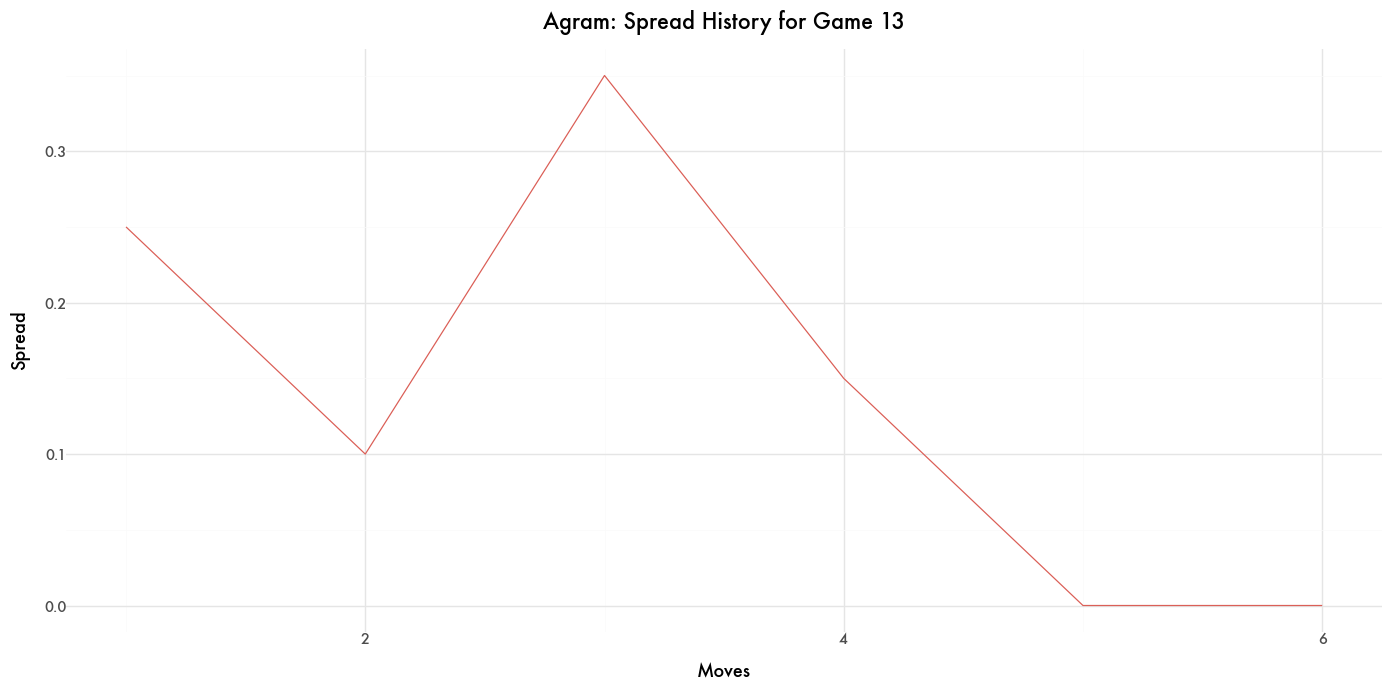

In [110]:
game = "Agram"
iter = "13"
splot = (ggplot(spreadframe[(spreadframe["run"] == iter) & (spreadframe["game"] == game)], 
       aes(x="pmove", y="spread", color="player"))
 + geom_line()
 + theme_minimal(base_family="Futura", base_size=13)
 + theme(legend_position='none', figure_size=(14, 7))
 + labs(x='Moves', y='Spread', title=game + ": Spread History for Game " + str(iter))
)
splot.save("Spread.png")
splot.show()

/opt/anaconda3/lib/python3.13/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 14 x 7 in image.
/opt/anaconda3/lib/python3.13/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: Spread.png


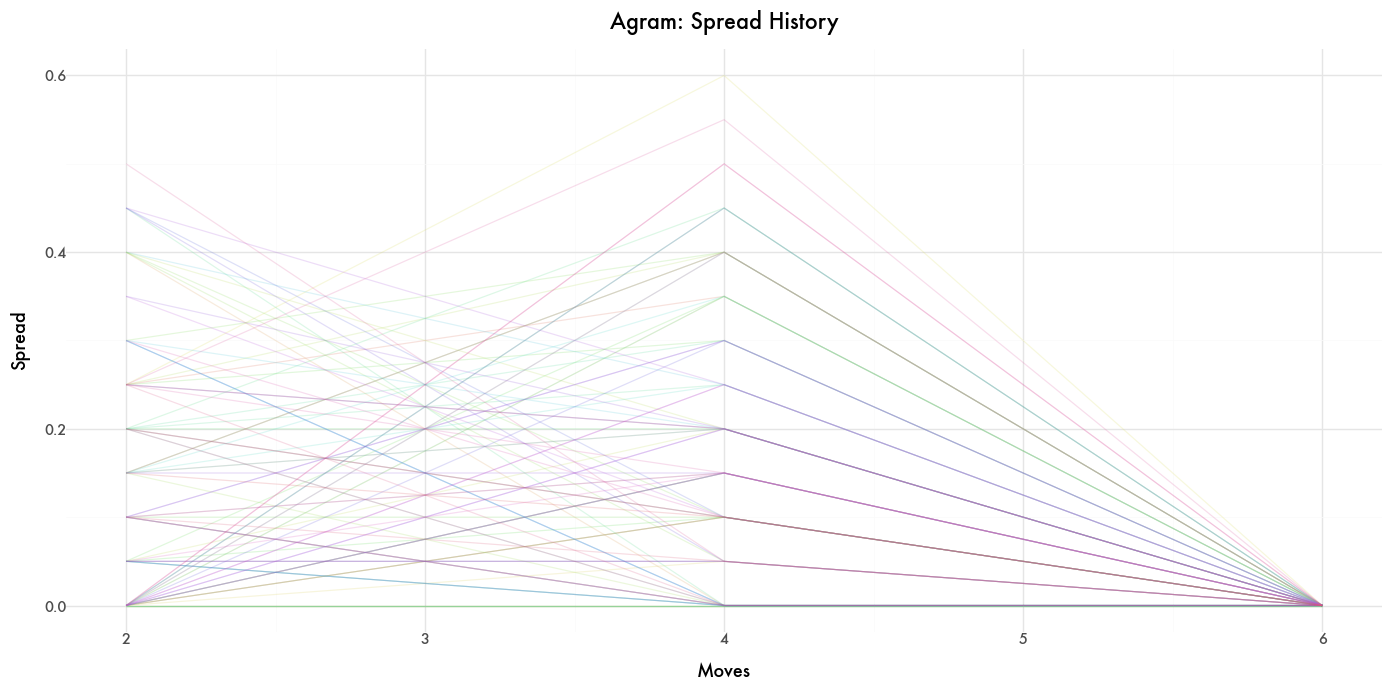

In [111]:
splot = (ggplot(spreadframe[(spreadframe["game"] == game) & (spreadframe["pmove"]%2 == 0)], 
       aes(x="pmove", y="spread", color="run"))
 + geom_line(alpha=0.2)
 + theme_minimal(base_family="Futura", base_size=13)
 + theme(legend_position='none', figure_size=(14, 7))
 + labs(x='Moves', y='Spread', title=game + ": Spread History")
)
splot.save("Spread.png")
splot.show()

In [112]:
spreadframe[(spreadframe["game"] == game)]

,game,numPlayers,ai,run,pmove,player,spread
0,Agram,3,PRR,1,1,0,0.25
1,Agram,3,PRR,1,2,0,0.00
2,Agram,3,PRR,1,3,0,0.00
3,Agram,3,PRR,1,4,0,0.10
4,Agram,3,PRR,1,5,0,0.00
...,...,...,...,...,...,...,...
595,Agram,3,PRR,100,2,0,0.25
596,Agram,3,PRR,100,3,0,0.25
597,Agram,3,PRR,100,4,0,0.35
598,Agram,3,PRR,100,5,0,0.15


/opt/anaconda3/lib/python3.13/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 14 x 7 in image.
/opt/anaconda3/lib/python3.13/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: Spread.png
/opt/anaconda3/lib/python3.13/site-packages/plotnine/geoms/geom_path.py:113: PlotnineWarning: geom_path: Each group consist of only one observation. Do you need to adjust the group aesthetic?
/opt/anaconda3/lib/python3.13/site-packages/plotnine/geoms/geom_path.py:113: PlotnineWarning: geom_path: Each group consist of only one observation. Do you need to adjust the group aesthetic?


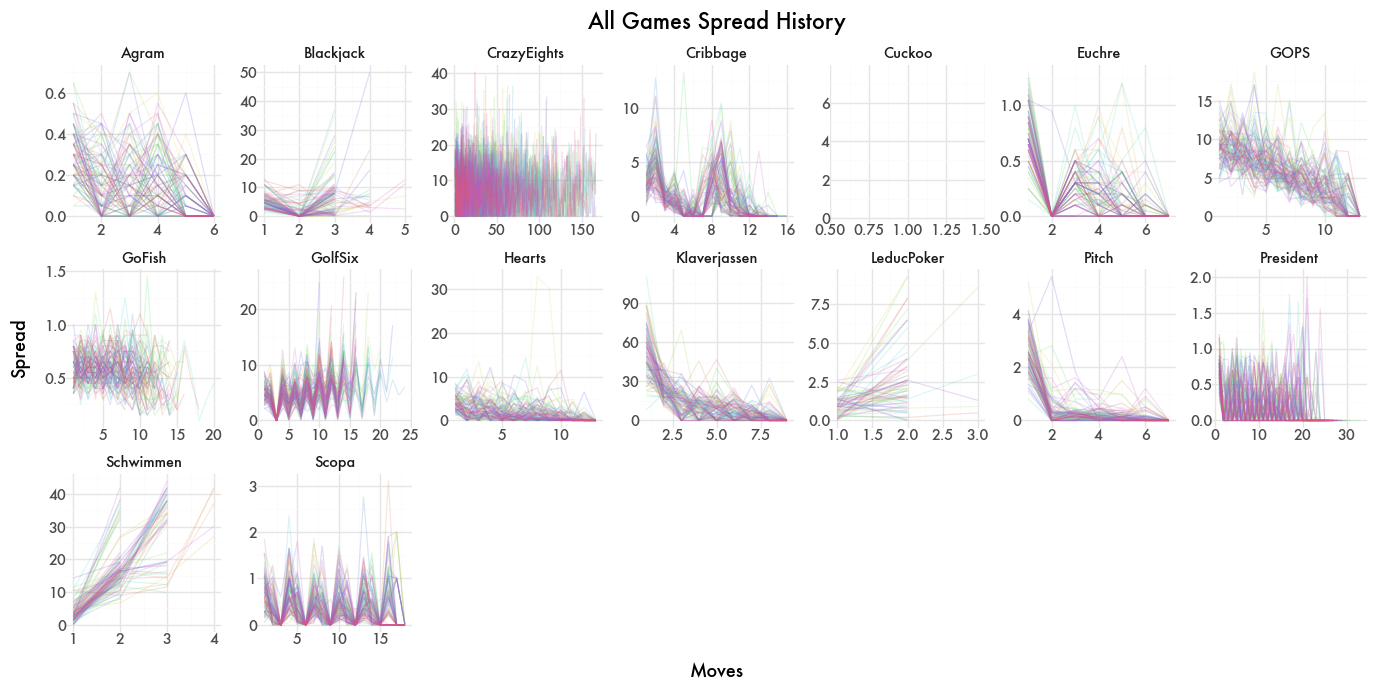

In [113]:
splot = (ggplot(spreadframe, 
       aes(x="pmove", y="spread", color="run"))
 + geom_line(alpha=0.2)
 + facet_wrap("game", scales = "free", ncol=7)
 + theme_minimal(base_family="Futura", base_size=13)
 + theme(legend_position='none', figure_size=(14, 7))
 + labs(x='Moves', y='Spread', title="All Games Spread History")
)
splot.save("Spread.png")
splot.show()

# Lead History 

First, we create the Dataframe for storing all of the game statistics for the lead histories, then we can use this to project multiple graphs.

The **Security** and **Drama** Heuristics are calculated as part of this process.

In [114]:
first = True
for index, row in gameframe.iterrows():
    gf = pd.read_csv(fileprefix + row["game"] + "/" + str(row["player"]) + "/" + "P" + "R" * (row["player"] - 1) + "/lead.csv")
    #gf = pd.read_csv(fileprefix + row["game"] + "/" + str(row["player"]) + "/" + "PPPPPP" + "/lead.csv")
    gf["game"] = row["game"]
    if first:
        leadframe = gf
        first = False
    else:
        leadframe = pd.concat([leadframe, gf])
leadframe

,game,numPlayers,ai,run,move,recorder,player,score,rank,rankestimate
0,Agram,3,PRR,1,1,1,1,0.45,1,0.725
1,Agram,3,PRR,1,1,1,2,0.35,1,0.675
2,Agram,3,PRR,1,1,1,3,0.20,0,0.600
3,Agram,3,PRR,1,2,1,1,0.35,1,0.675
4,Agram,3,PRR,1,2,1,2,0.35,1,0.675
...,...,...,...,...,...,...,...,...,...,...
3795,Scopa,2,PR,100,17,1,2,4.00,0,1.000
3796,Scopa,2,PR,100,18,1,1,0.00,1,0.000
3797,Scopa,2,PR,100,18,1,2,4.00,0,1.000
3798,Scopa,2,PR,100,19,1,1,0.00,1,0.000


In [115]:
first = True
for game in gameframe["game"]:
    pv = gameframe[gameframe["game"] == game]["player"].values[0]
    myl = leadframe[leadframe["game"] == game]
    for run in range(1, 101):
        for player in range(1, pv + 1):
            myl2 = myl[(myl["run"] == run)  & (myl["player"] == player)]
            x = myl2["rankestimate"]
            length = myl2["move"].max()
            px = [x / (length - 1) for x in range(length)]
            f = interp1d(px, x)
            xnew = np.linspace(0, 1, num=101)
            ynew = f(xnew)
            n = pd.DataFrame([xnew, ynew], index=["portion", "estimate"]).T
            n["game"] = game
            n["run"] = run
            n["player"] = player
            n["rank"] = myl2["rank"].values[0]
            if first:
                leads = n
                first = False
            else:
                leads = pd.concat([leads, n])

In [116]:
leads

,portion,estimate,game,run,player,rank
0,0.00,0.725,Agram,1,1,1
1,0.01,0.722,Agram,1,1,1
2,0.02,0.719,Agram,1,1,1
3,0.03,0.716,Agram,1,1,1
4,0.04,0.713,Agram,1,1,1
...,...,...,...,...,...,...
96,0.96,1.000,Scopa,100,2,0
97,0.97,1.000,Scopa,100,2,0
98,0.98,1.000,Scopa,100,2,0
99,0.99,1.000,Scopa,100,2,0


In [117]:
leads["player"] = leads["player"].astype(str)
leads["run"] = leads["run"].astype(str)
leads["rank"] = leads["rank"].astype(str)
leads

,portion,estimate,game,run,player,rank
0,0.00,0.725,Agram,1,1,1
1,0.01,0.722,Agram,1,1,1
2,0.02,0.719,Agram,1,1,1
3,0.03,0.716,Agram,1,1,1
4,0.04,0.713,Agram,1,1,1
...,...,...,...,...,...,...
96,0.96,1.000,Scopa,100,2,0
97,0.97,1.000,Scopa,100,2,0
98,0.98,1.000,Scopa,100,2,0
99,0.99,1.000,Scopa,100,2,0


/opt/anaconda3/lib/python3.13/site-packages/mizani/palettes.py:705: UserWarning: Palette can return a maximum of 4 values. 5 values requested.
/opt/anaconda3/lib/python3.13/site-packages/plotnine/geoms/geom_path.py:100: PlotnineWarning: geom_path: Removed 101 rows containing missing values.


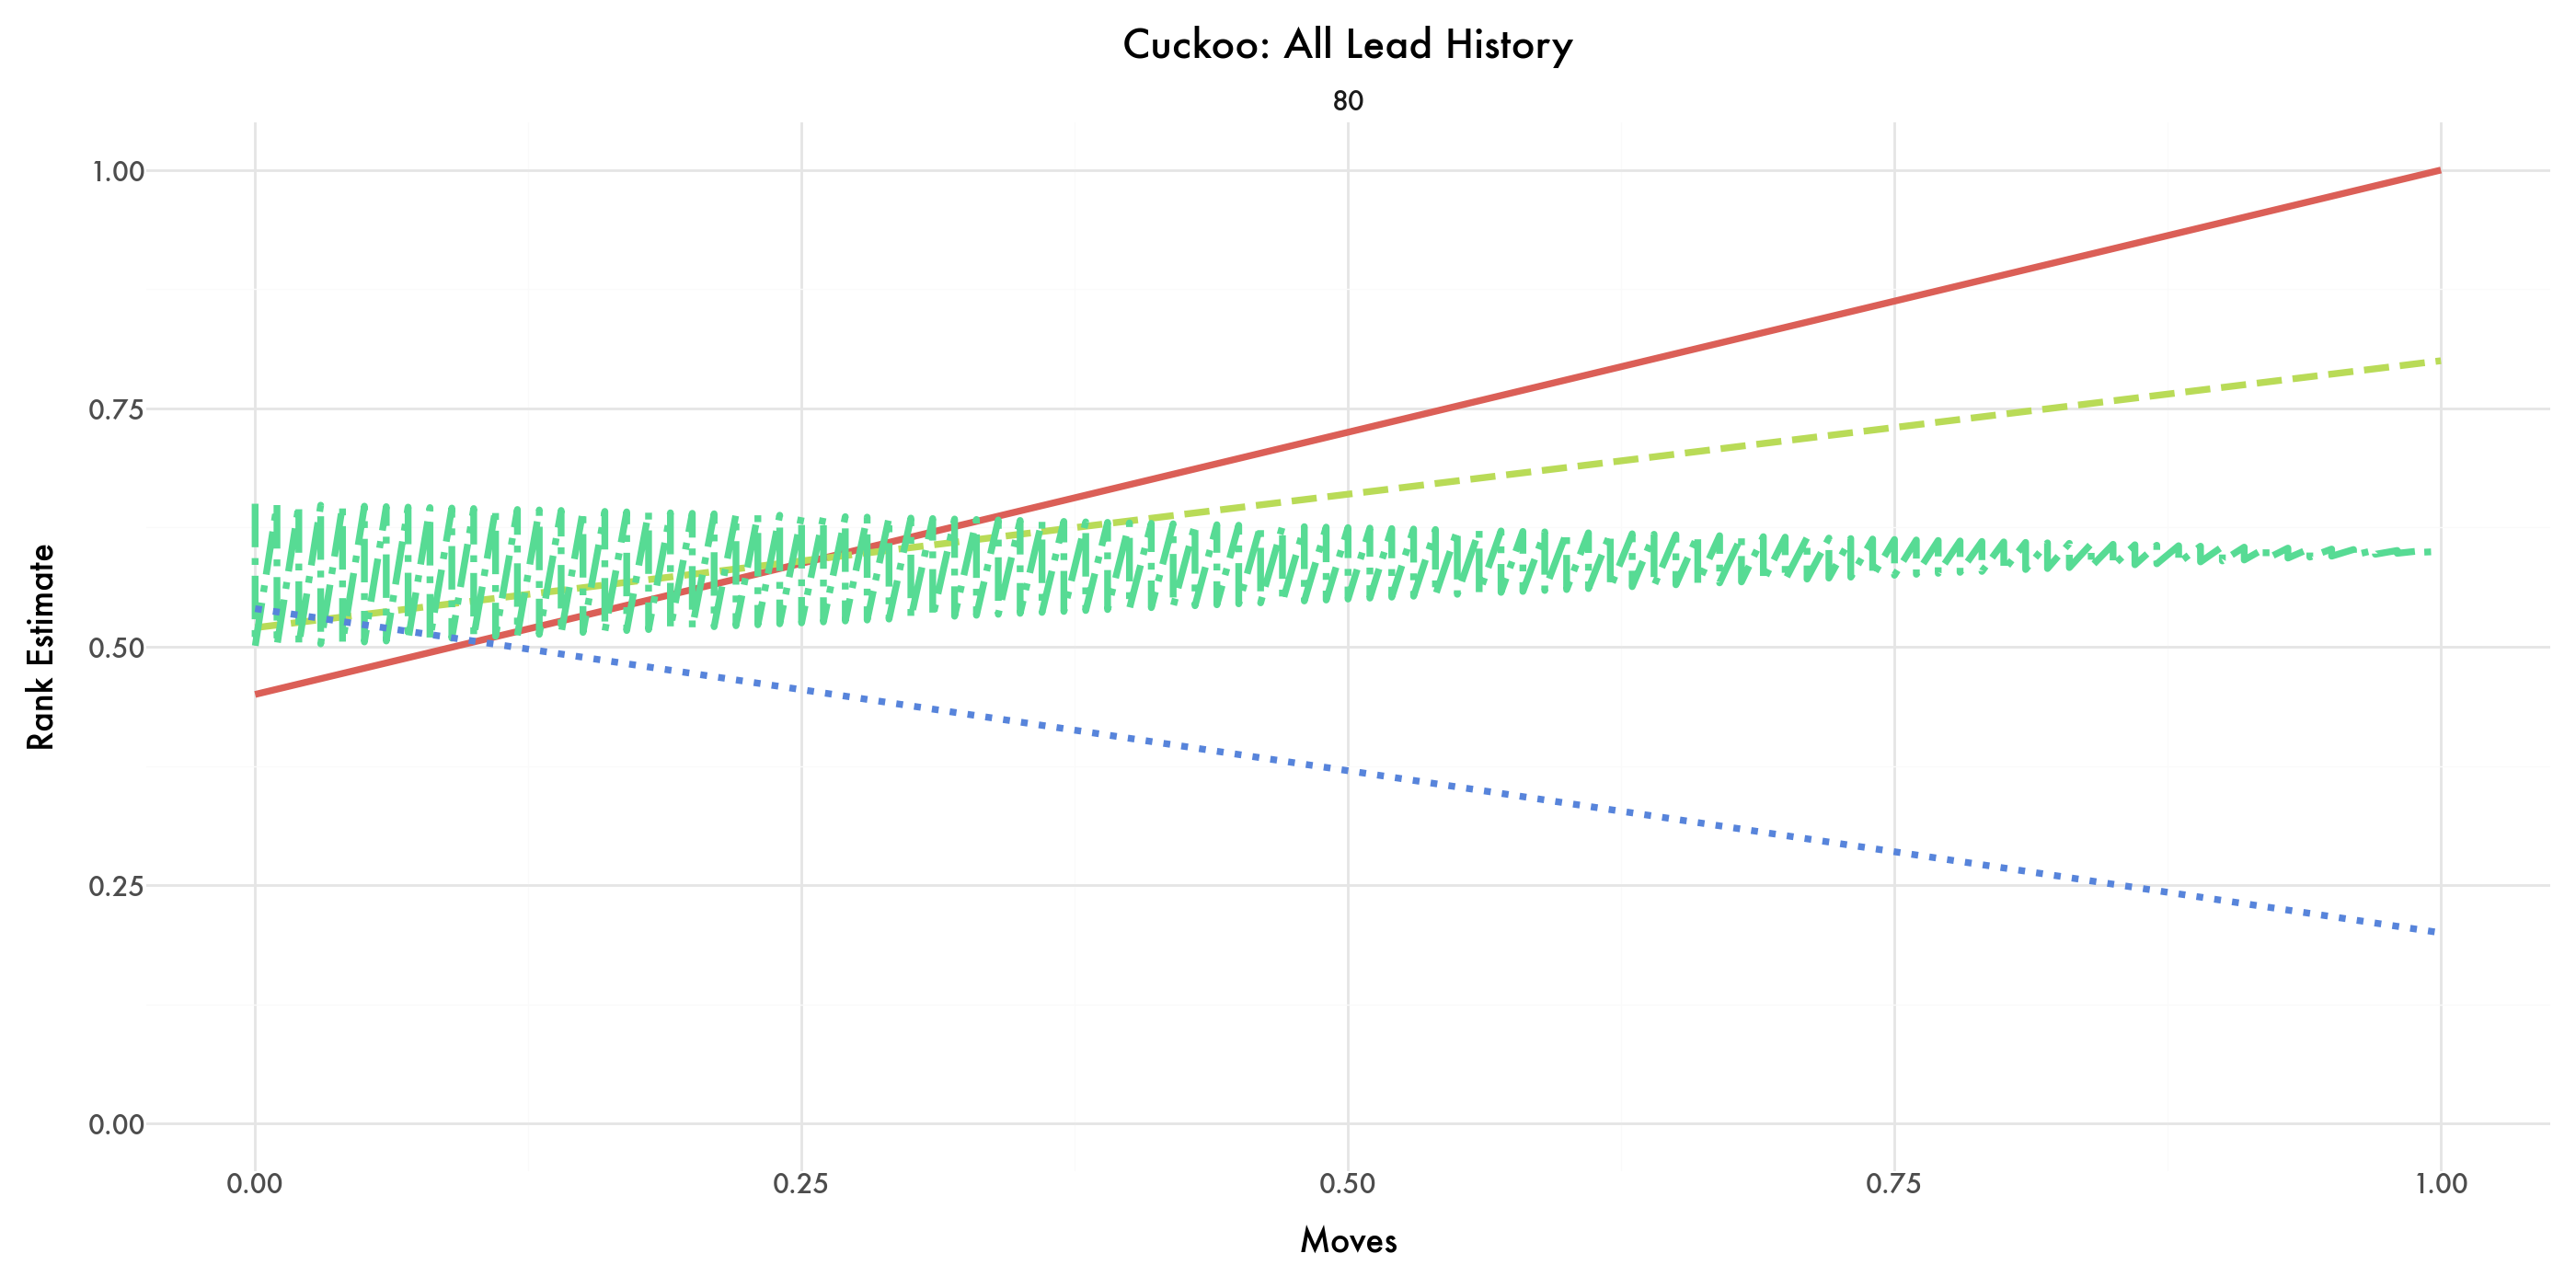

In [148]:
game = "Cuckoo"
iter="80"
(ggplot(leads[(leads["game"] == game) & (leads["run"]== iter)], 
       aes(x="portion", y="estimate", color="rank"))
 + geom_line(aes(linetype="rank"), size=1.5)
 + ylim(0, 1)
 + facet_wrap("run", scales = "free_x")
 + theme_minimal(base_family="Futura", base_size=13)
 + theme(legend_position='none', figure_size=(14, 7))
 + labs(x='Moves', y='Rank Estimate', title=game + ": All Lead History")
)

In [149]:
(ggplot(leads[(leads["game"] == game)], 
       aes(x="portion", y="estimate", color="rank"))
 + geom_line(aes(linetype="rank"))
 + ylim(0, 1)
 + facet_wrap("run", scales = "free_x")
 + theme_minimal(base_family="Futura", base_size=8)
 + theme(legend_position='none', figure_size=(15, 15))
 + labs(x='Moves', y='Rank Estimate', title=game + ": All Lead History")
)

/opt/anaconda3/lib/python3.13/site-packages/mizani/palettes.py:705: UserWarning: Palette can return a maximum of 4 values. 6 values requested.
/opt/anaconda3/lib/python3.13/site-packages/plotnine/geoms/geom_path.py:100: PlotnineWarning: geom_path: Removed 202 rows containing missing values.


ValueError: Unrecognized linestyle: nan

/opt/anaconda3/lib/python3.13/site-packages/plotnine/layer.py:364: PlotnineWarning: geom_smooth : Removed 2 rows containing missing values.


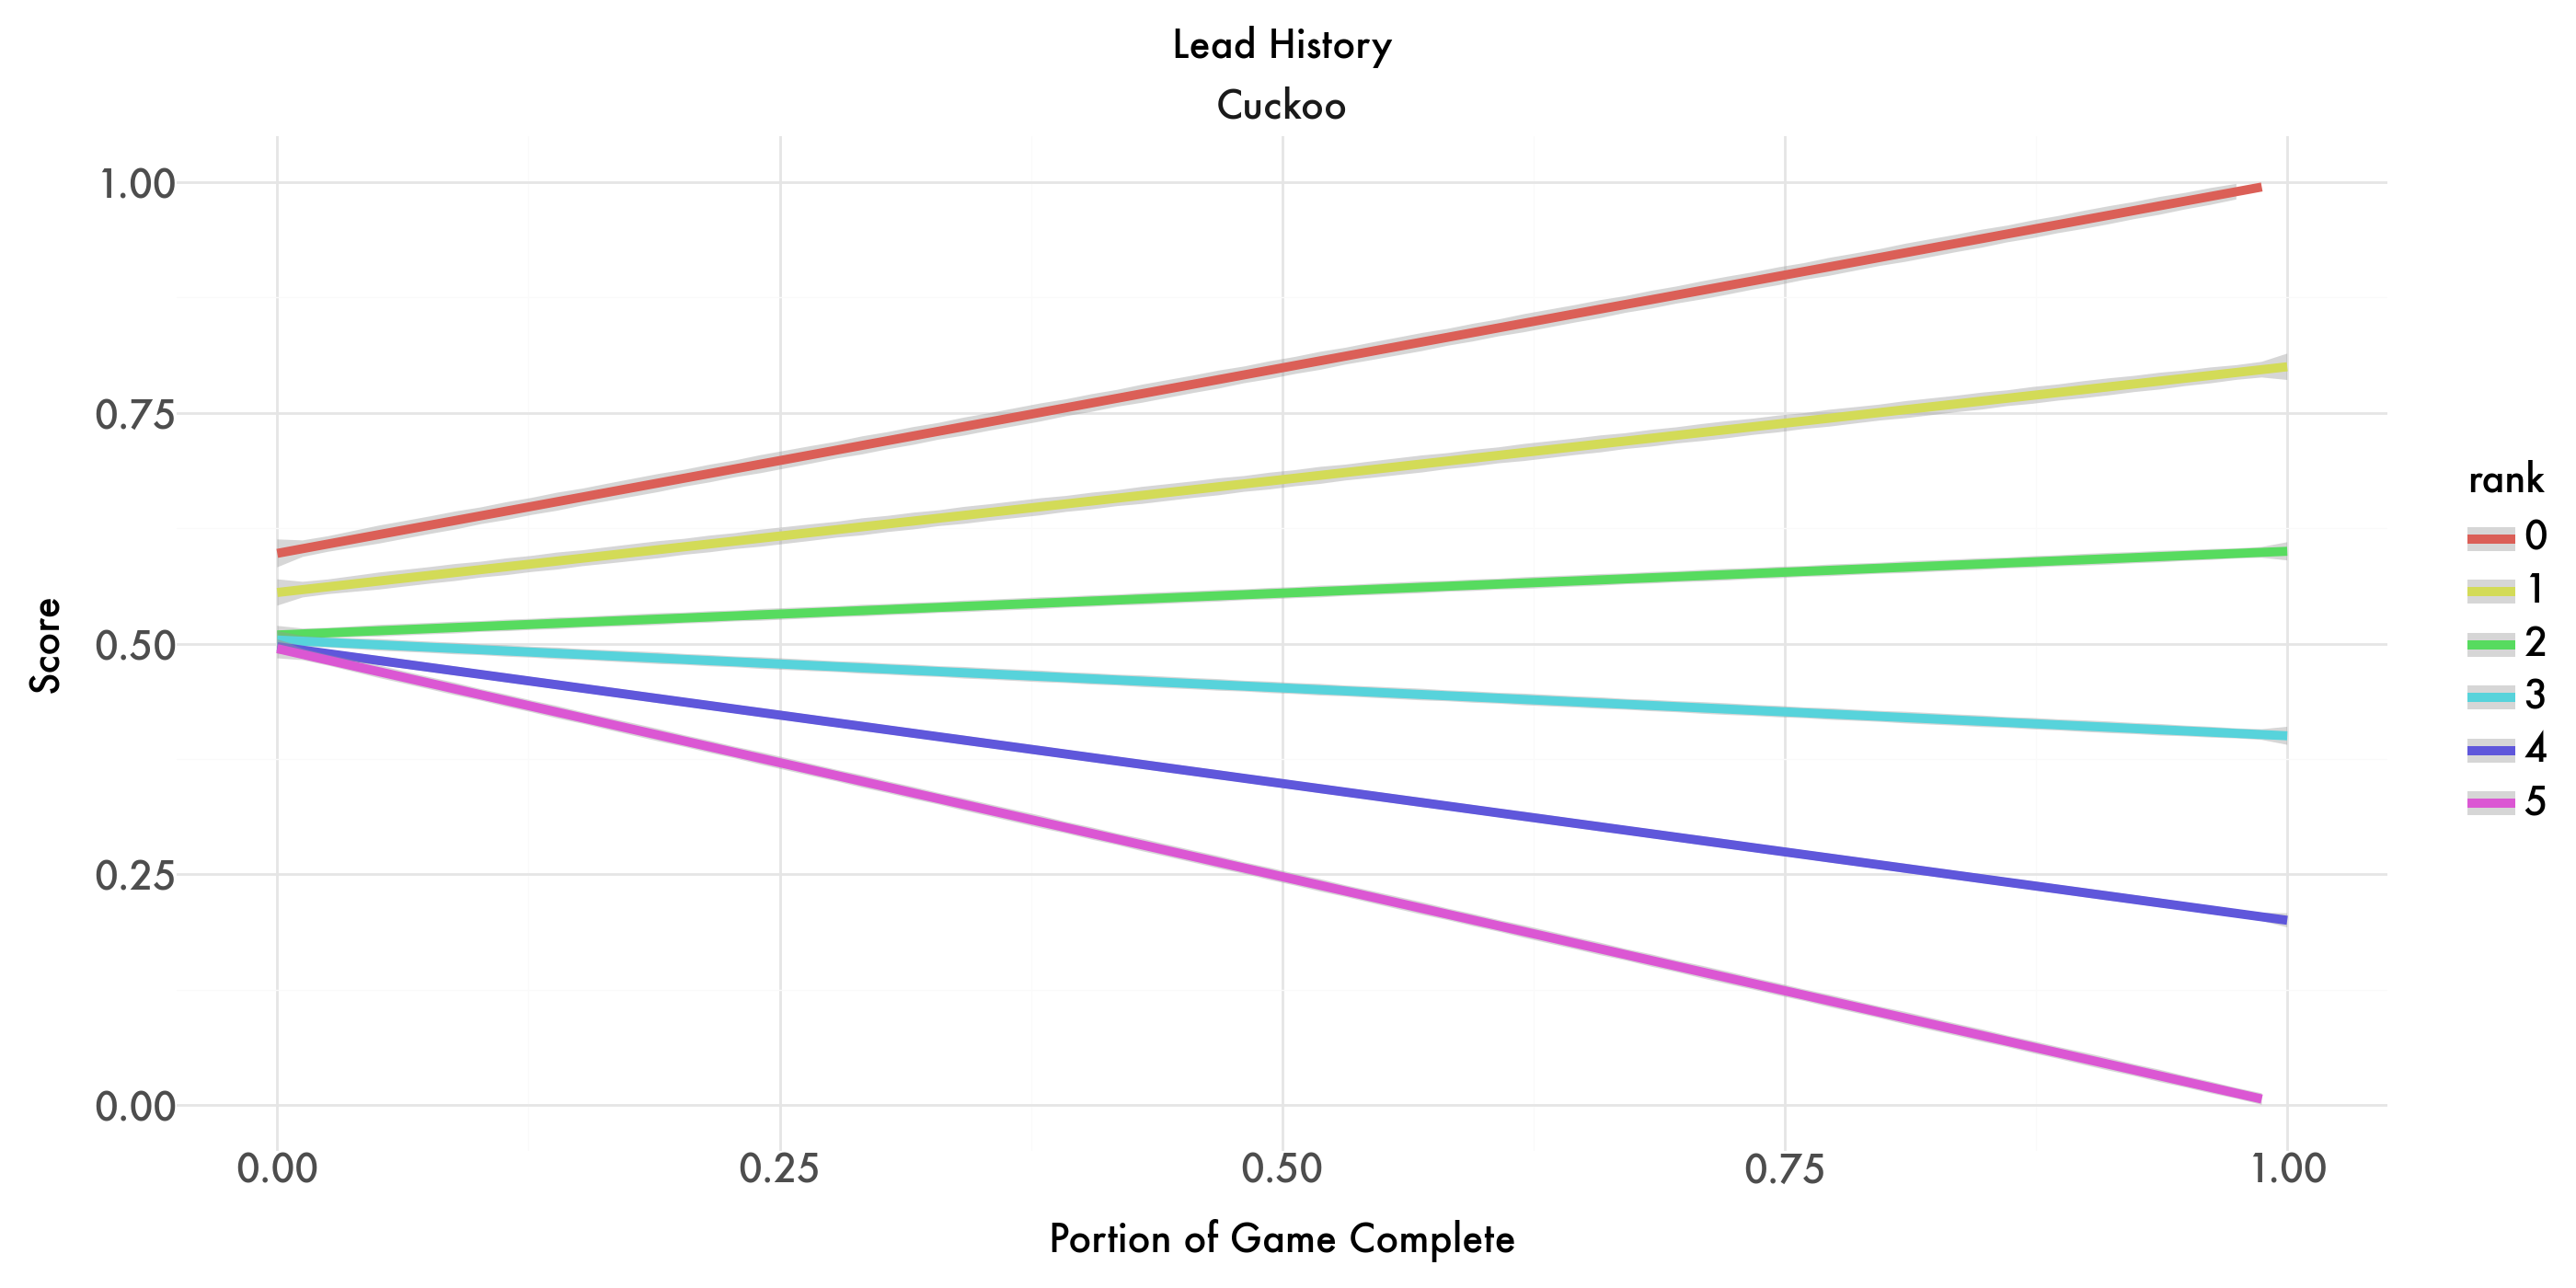

In [150]:
(ggplot(leads[(leads["game"] == game)], 
       aes(x="portion", y="estimate", color="rank"))
 + geom_smooth(method="loess", size=2, span=0.1)
 + ylim(0, 1)
 + facet_wrap("game")
 + theme_minimal(base_family="Futura", base_size=13)
 + theme(figure_size=(14, 7), text=element_text(size=15))
 + labs(x='Portion of Game Complete', y='Score', title="Lead History")
)

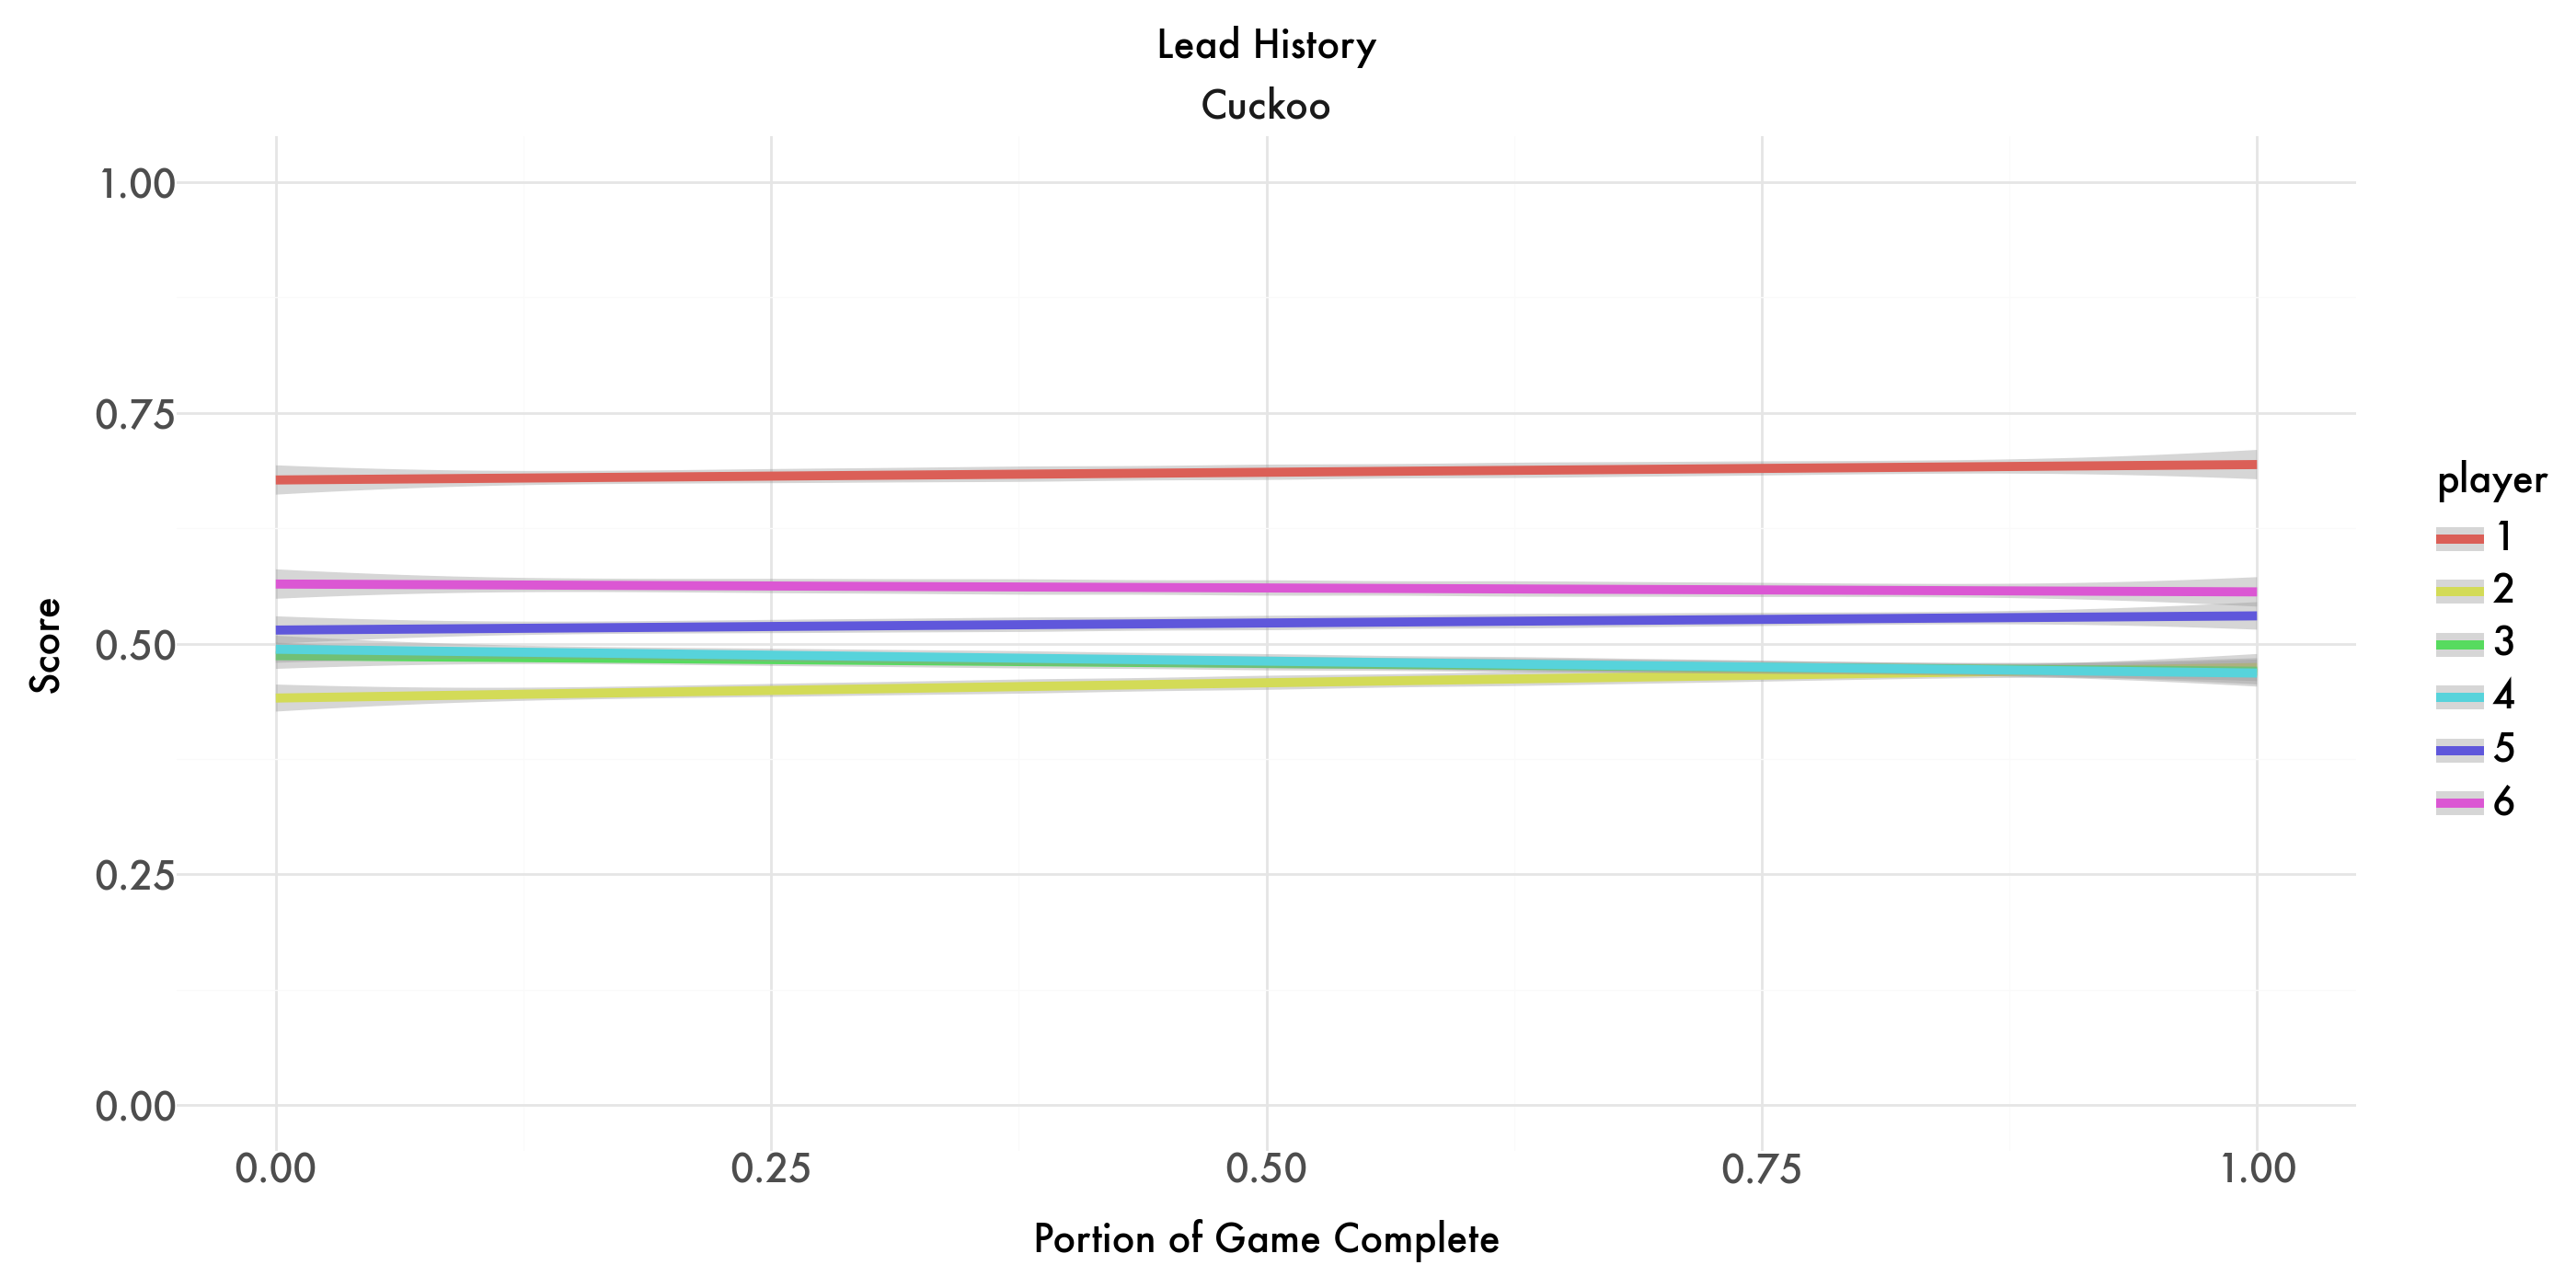

In [151]:
(ggplot(leads[(leads["game"] == game)], 
       aes(x="portion", y="estimate", color="player"))
 + geom_smooth(method="loess", size=2)
 + ylim(0, 1)
 + facet_wrap("game")
 + theme_minimal(base_family="Futura", base_size=13)
 + theme(figure_size=(14, 7), text=element_text(size=15))
 + labs(x='Portion of Game Complete', y='Score', title="Lead History")
)

In [123]:
lplot = (ggplot(leadframe[(leadframe["game"] == "LeducPoker") | (leadframe["game"] == "Rummy") | (leadframe["game"] == "President") | (leadframe["game"] == "GoFish") | (leadframe["game"] == "CrazyEights") | (leadframe["game"] == "Agram") | (leadframe["game"] == "Skittgube") | (leadframe["game"] == "GolfSix")| (leadframe["game"] == "Schwimmen")| (leadframe["game"] == "Whist")| (leadframe["game"] == "Klaverjassen")| (leadframe["game"] == "Euchre")| (leadframe["game"] == "Pitch")| (leadframe["game"] == "Cuckoo")| (leadframe["game"] == "GOPS")| (leadframe["game"] == "Scopa")| (leadframe["game"] == "Hearts") | (leadframe["game"] == "Blackjack")| (leadframe["game"] == "Cribbage")| (leadframe["game"] == "Sueca")], 
       aes(x="move", y="rankestimate", color="rank"))
 + geom_smooth(method="loess")
 + ylim(0, 1)
 + facet_wrap("game", scales="free_x")
 + theme_minimal(base_family="Futura", base_size=13)
 + theme(legend_position='none', figure_size=(14, 7))
 + labs(x='Portion of Game Complete', y='Rank Estimate', title="Lead History")
)
lplot.save("Lead.png")
lplot.show()

/opt/anaconda3/lib/python3.13/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 14 x 7 in image.
/opt/anaconda3/lib/python3.13/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: Lead.png


ValueError: b'There are other near singularities as well. 1.01\n'